# Pipeline de préparation des données + entraînement

**Projet :** Diagnostic assisté et tri d'urgence multimodal en télémédecine — prédire le niveau d'urgence (0 : non urgent, 1 : urgence relative, 2 : urgence vitale).

**Plan du notebook :**
1. Imports et configuration
2. Chargement + exploration + détection / suppression des doublons stricts
3. Visualisation des NaN (missingno, **avant** nettoyage)
4. **Étape 1 — Retrait des colonnes non éthiques**
5. **Étape 2 — Note RGPD (colonnes personnelles)**
6. **Étape 3 — Retrait des colonnes inexploitables (> 50 % NaN)**
7. **Étape 4 — Règles métiers** : valeurs hors plage → NaN
8. **Étape 5 — Détection d'outliers (IQR)** → NaN
9. **Étape 6 — Suppression des 2 % de lignes les plus vides**
10. **Étape 7 — Imputation KNN**
11. Casting et normalisation légère du texte
12. Visualisation des NaN (missingno, **après** nettoyage)
13. Sauvegarde `data/processed/dataset_telemed_processed.csv`
14. **Feature engineering** : standardisation (ddof = 1), normalisation, encodage, TF-IDF
15. Validation croisée K-Fold stratifiée
16. Entraînement Random Forest, XGBoost, MLP
17. Courbes : matrices de confusion, ROC, learning curves
18. Récapitulatif

Chaque étape clé est tracée comme un run MLflow dans l'expérience `data_prep_pipeline`.


## 1. Imports et configuration

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import mlflow

from sklearn.impute import KNNImputer
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, balanced_accuracy_score,
    confusion_matrix,
    roc_curve, auc,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'dataset_telemed.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_PATH = PROCESSED_DIR / 'dataset_telemed_processed.csv'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = PROJECT_ROOT / 'mlflow_artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(MLFLOW_DIR.as_uri())
EXPERIMENT_NAME = 'data_prep_pipeline'
mlflow.set_experiment(EXPERIMENT_NAME)

print('Raw path     :', RAW_PATH)
print('Output path  :', PROCESSED_PATH)
print('Tracking URI :', mlflow.get_tracking_uri())

Raw path     : /Users/sebastien/Certification-Atlas-CISIA/data/raw/dataset_telemed.csv
Output path  : /Users/sebastien/Certification-Atlas-CISIA/data/processed/dataset_telemed_processed.csv
Tracking URI : file:///Users/sebastien/Certification-Atlas-CISIA/mlruns


/Users/sebastien/Certification-Atlas-CISIA/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 2. Chargement du dataset brut

On lit le CSV brut et on regarde rapidement la forme, les types et les premières lignes.

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print('Shape :', df_raw.shape)
df_raw.head()

Shape : (10080, 13)


,patient_id,sexe,age,zone_vie,source,freq_cardiaque,tension_sys,temp,sat_oxygene,antecedents,duree_symptomes,description_symptomes,niveau_urgence
0,P0001,H,19.0,R,appel,110.4,128.6,37.8,93.8,0.0,62.2,Douleur abdominale aiguë localisée dans le qua...,1
1,P0002,H,56.0,U,appel,72.0,153.5,36.0,100.0,1.0,45.8,Demande de certificat médical pour une activit...,0
2,P0003,H,1.0,U,appel,70.4,117.7,36.9,97.6,0.0,8.0,Douleur dorsale chronique sans aggravation réc...,0
3,P0004,H,7.0,R,appel,84.7,126.3,37.1,96.1,1.0,28.5,Besoin d'un avis suite à une fin de traitement...,0
4,P0005,F,28.0,R,appel,114.3,168.1,38.6,95.1,0.0,54.6,Vomissements répétés et incapacité totale à s'...,1


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             10080 non-null  object 
 1   sexe                   10058 non-null  object 
 2   age                    10063 non-null  float64
 3   zone_vie               10063 non-null  object 
 4   source                 10062 non-null  object 
 5   freq_cardiaque         10055 non-null  float64
 6   tension_sys            10063 non-null  float64
 7   temp                   10063 non-null  float64
 8   sat_oxygene            10070 non-null  float64
 9   antecedents            10065 non-null  float64
 10  duree_symptomes        10067 non-null  float64
 11  description_symptomes  10063 non-null  object 
 12  niveau_urgence         10080 non-null  int64  
dtypes: float64(7), int64(1), object(5)
memory usage: 1023.9+ KB


In [4]:
print('Valeurs manquantes par colonne :')
print(df_raw.isna().sum())
print('\nLignes totalement dupliquées :', df_raw.duplicated().sum())
print('patient_id dupliqués         :', df_raw['patient_id'].duplicated().sum())
print('\nDistribution de la cible niveau_urgence :')
print(df_raw['niveau_urgence'].value_counts(dropna=False).sort_index())

Valeurs manquantes par colonne :
patient_id                0
sexe                     22
age                      17
zone_vie                 17
source                   18
freq_cardiaque           25
tension_sys              17
temp                     17
sat_oxygene              10
antecedents              15
duree_symptomes          13
description_symptomes    17
niveau_urgence            0
dtype: int64

Lignes totalement dupliquées : 77
patient_id dupliqués         : 80

Distribution de la cible niveau_urgence :
niveau_urgence
0    5053
1    3551
2    1476
Name: count, dtype: int64


In [5]:
# Aperçu des lignes en doublon strict (le décompte est en cellule 6).
dups = df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns))
print(f'{len(dups)} lignes dupliquées, {df_raw.duplicated().sum()} à supprimer.')
dups.head(10)


154 lignes dupliquées, 77 à supprimer.


,patient_id,sexe,age,zone_vie,source,freq_cardiaque,tension_sys,temp,sat_oxygene,antecedents,duree_symptomes,description_symptomes,niveau_urgence
35,P0036,H,73.0,R,appel,85.7,179.7,38.0,99.1,1.0,15.9,Traumatisme direct sur le nez avec saignement ...,1
10041,P0036,H,73.0,R,appel,85.7,179.7,38.0,99.1,1.0,15.9,Traumatisme direct sur le nez avec saignement ...,1
39,P0040,F,94.0,U,chat,156.5,205.4,40.4,83.6,0.0,64.5,Réaction anaphylactique avec gonflement du vis...,2
10045,P0040,F,94.0,U,chat,156.5,205.4,40.4,83.6,0.0,64.5,Réaction anaphylactique avec gonflement du vis...,2
107,P0108,H,20.0,R,appel,94.1,190.8,39.0,94.7,0.0,61.7,Essoufflement inhabituel lors d'un effort phys...,1
10063,P0108,H,20.0,R,appel,94.1,190.8,39.0,94.7,0.0,61.7,Essoufflement inhabituel lors d'un effort phys...,1
251,P0252,F,10.0,R,appel,61.5,107.3,36.8,98.4,0.0,63.6,"Petite éruption cutanée sur le bras, pas de dé...",0
10037,P0252,F,10.0,R,appel,61.5,107.3,36.8,98.4,0.0,63.6,"Petite éruption cutanée sur le bras, pas de dé...",0
321,P0322,H,31.0,R,chat,71.2,131.2,37.5,95.6,1.0,1.3,Simple demande d'information sur les horaires ...,0
10030,P0322,H,31.0,R,chat,71.2,131.2,37.5,95.6,1.0,1.3,Simple demande d'information sur les horaires ...,0


In [6]:
# Déduplication + vérification.
# On supprime les 77 doublons stricts identifiés ci-dessus.
# On garde df_raw intact (état brut) et on crée df = la version dédupliquée
# qui servira pour la suite de la pipeline.
print(f'Avant : df_raw.duplicated().sum() = {df_raw.duplicated().sum()}')
df = df_raw.drop_duplicates().reset_index(drop=True).copy()
print(f'Après : df.duplicated().sum()     = {df.duplicated().sum()}')
print(f'Lignes : {len(df_raw)} -> {len(df)} (supprimées : {len(df_raw) - len(df)})')


Avant : df_raw.duplicated().sum() = 77
Après : df.duplicated().sum()     = 0
Lignes : 10080 -> 10003 (supprimées : 77)


## 2bis. Exploration de la cible et des signaux cliniques

Avant tout nettoyage : répartition des 3 niveaux d'urgence, puis boxplots des variables
numériques par niveau d'urgence (une boîte par classe : on voit d'un coup quelles
variables séparent les classes — **et lesquelles non, ce qui est tout aussi instructif**).

- **Classe 2 (urgence vitale) minoritaire (~14,6 %)** → l'accuracy seule serait trompeuse,
  d'où le suivi du *recall classe 2* et des *erreurs critiques* dans l'évaluation.
- **Les 4 constantes vitales portent le signal** (corrélation avec l'urgence) :
  freq_cardiaque (+0,68), sat_oxygene (−0,67), temp (+0,65), tension_sys (+0,64).
  Sur les boxplots, la classe 2 (rouge) se détache nettement (SaO2 basse, fièvre, tachycardie, hypertension).
- **age et duree_symptomes ne corrèlent pas** avec l'urgence (corr ≈ 0 ; nuages parfaitement
  boîtes superposées). On les **garde dans l'analyse pour le montrer** plutôt que de les retirer en silence :
  - *rigueur* : on documente les variables vérifiées **et écartées**, pas seulement celles qui marchent ;
  - *éthique / RGPD* : l'absence de corrélation de l'**âge** prouve que le tri repose sur l'état
    clinique et non sur l'âge → pas de biais d'âge dans les données (cf. section éthique).
- **Variables catégorielles non discriminantes** : sexe, zone_vie, source, antécédents
  donnent des barres identiques (~14,6 % d'urgences vitales partout). Pour les variables
  *sensibles* (sexe, zone_vie), c'est un argument d'**équité** : pas de biais dans les données.
- *Aucune hypothermie* dans les données (temp ∈ [35,5 ; 41,5] °C) : seule la fièvre est un danger appris.


Répartition des niveaux d urgence :
 classe          libelle  effectif  pourcentage
      0       non urgent      5014         50.1
      1 urgence relative      3528         35.3
      2   urgence vitale      1461         14.6


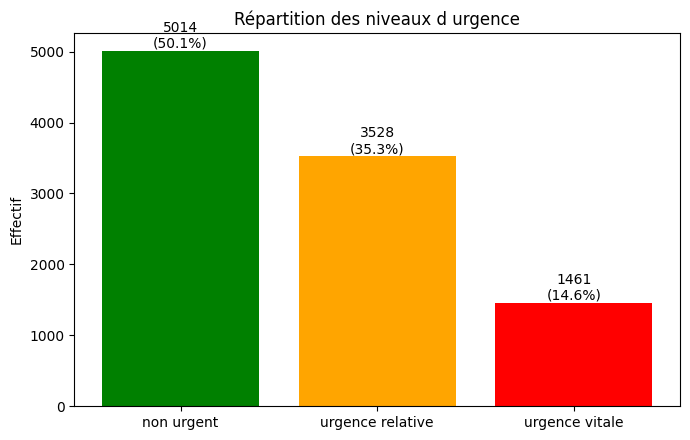

In [7]:
URGENCY_LABELS = {0: 'non urgent', 1: 'urgence relative', 2: 'urgence vitale'}
URGENCY_COLORS = {0: 'green', 1: 'orange', 2: 'red'}

counts = df['niveau_urgence'].value_counts().sort_index()
dist = pd.DataFrame({
    'classe': counts.index,
    'libelle': [URGENCY_LABELS[c] for c in counts.index],
    'effectif': counts.values,
    'pourcentage': (counts.values / len(df) * 100).round(1),
})
print('Répartition des niveaux d urgence :')
print(dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([URGENCY_LABELS[c] for c in dist['classe']], dist['effectif'],
              color=[URGENCY_COLORS[c] for c in dist['classe']])
ax.set_title('Répartition des niveaux d urgence'); ax.set_ylabel('Effectif')
for bar, eff, pct in zip(bars, dist['effectif'], dist['pourcentage']):
    ax.text(bar.get_x() + bar.get_width()/2, eff + 40, f'{eff}\n({pct}%)', ha='center')
plt.tight_layout(); plt.show()


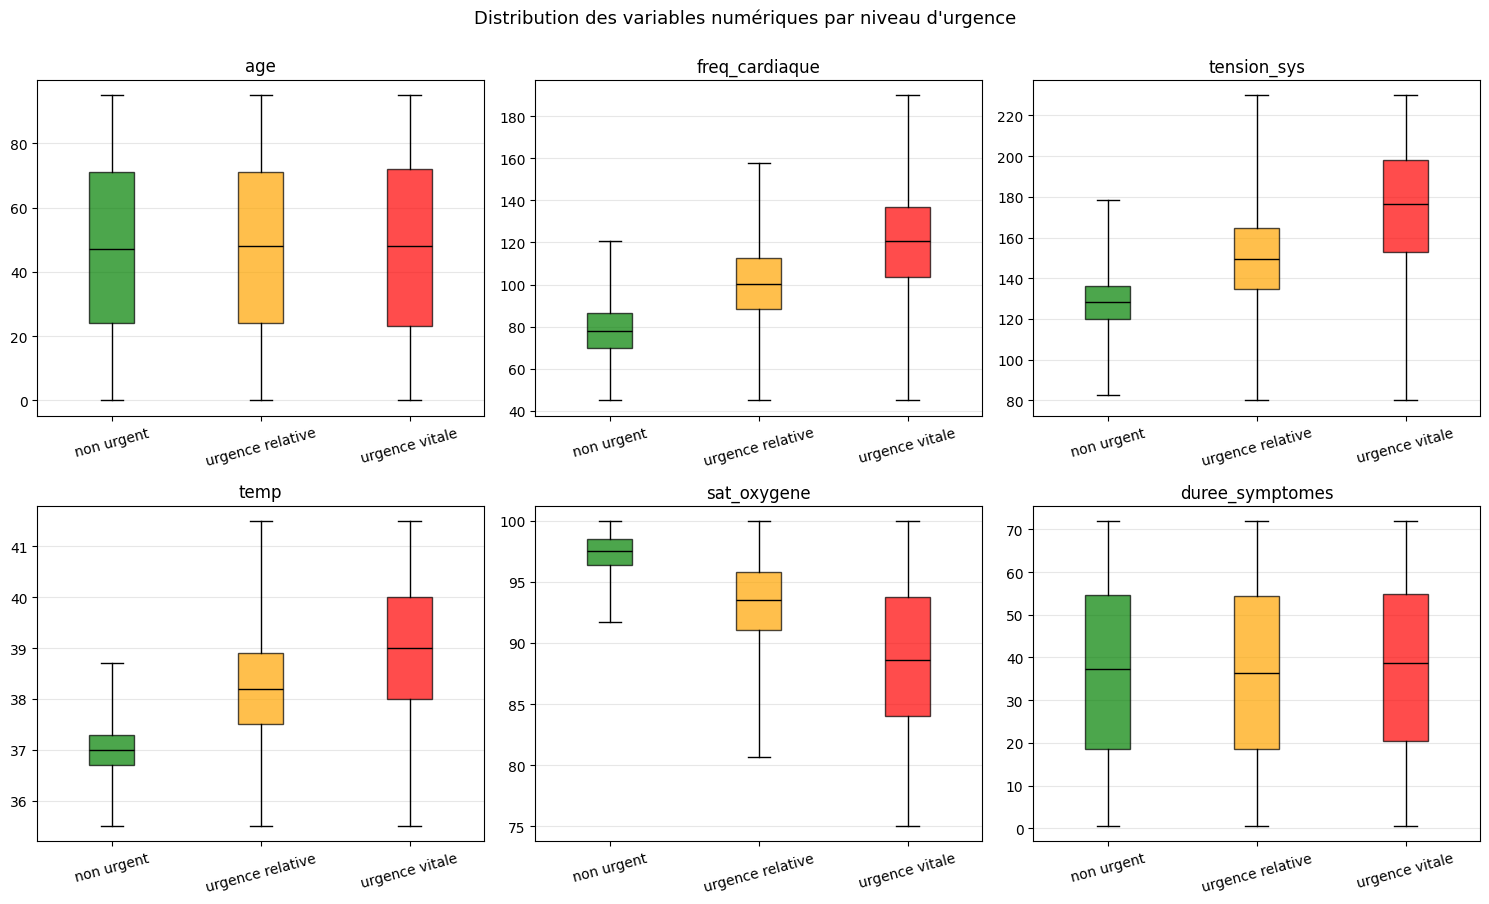

In [8]:
# distribution des variables numériques par classe (médianes en escalier = sépare, boîtes alignées = non)
num_cols_eda = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'duree_symptomes']
classes_eda = sorted(df['niveau_urgence'].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, v in zip(axes.ravel(), num_cols_eda):
    data = [df.loc[df['niveau_urgence'] == c, v].dropna() for c in classes_eda]
    bp = ax.boxplot(data, tick_labels=[URGENCY_LABELS[c] for c in classes_eda],
                    patch_artist=True, showfliers=False, whis=(0,100))
    for patch, c in zip(bp['boxes'], classes_eda):
        patch.set_facecolor(URGENCY_COLORS[c]); patch.set_alpha(0.7)
    for med in bp['medians']:
        med.set_color('black')
    ax.set_title(v); ax.tick_params(axis='x', rotation=15); ax.grid(axis='y', alpha=0.3)
fig.suptitle("Distribution des variables numériques par niveau d'urgence", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()


In [9]:
# comptage des cas par catégorie et niveau d'urgence (proportions identiques = pas de séparation)
cat_cols_eda = ['sexe', 'zone_vie', 'source', 'antecedents']
for col in cat_cols_eda:
    print(f'\n=== {col} : nombre de cas par niveau d urgence ===')
    ct = pd.crosstab(df[col], df['niveau_urgence'], margins=True, margins_name='Total')
    ct.columns = [URGENCY_LABELS.get(c, c) for c in ct.columns]
    print(ct.to_string())



=== sexe : nombre de cas par niveau d urgence ===
       non urgent  urgence relative  urgence vitale  Total
sexe                                                      
F            2530              1725             735   4990
H            2471              1798             722   4991
Total        5001              3523            1457   9981

=== zone_vie : nombre de cas par niveau d urgence ===
          non urgent  urgence relative  urgence vitale  Total
zone_vie                                                     
R               2485              1736             711   4932
U               2523              1783             748   5054
Total           5008              3519            1459   9986

=== source : nombre de cas par niveau d urgence ===
        non urgent  urgence relative  urgence vitale  Total
source                                                     
appel         2564              1799             741   5104
chat          2441              1722             718   4

## 3. Visualisation des valeurs manquantes — AVANT nettoyage

On utilise `missingno` avec deux visus très lisibles :
- `msno.matrix(df)` : une carte ligne-par-ligne où chaque cellule manquante apparaît en blanc.
- `msno.bar(df)` : un histogramme de la complétude par colonne.

**À propos de la `sparkline`** (la petite courbe à droite de la matrice) : pour chaque ligne du dataset, elle indique **le nombre de colonnes remplies**. Les annotations donnent les valeurs min (en bas) et max (en haut). C'est pratique pour repérer en un coup d'œil les lignes anormalement vides (creux dans la courbe).

**Pourquoi on échantillonne** : avec ~10 000 lignes compressées dans ~600 pixels de hauteur, chaque ligne occupe ~0.06 px et les 17 NaN d'une colonne deviennent invisibles. Sur un échantillon de 500 lignes, chaque ligne occupe ~1 px et les NaN sont visibles comme traits blancs distincts.

<Figure size 1400x600 with 0 Axes>

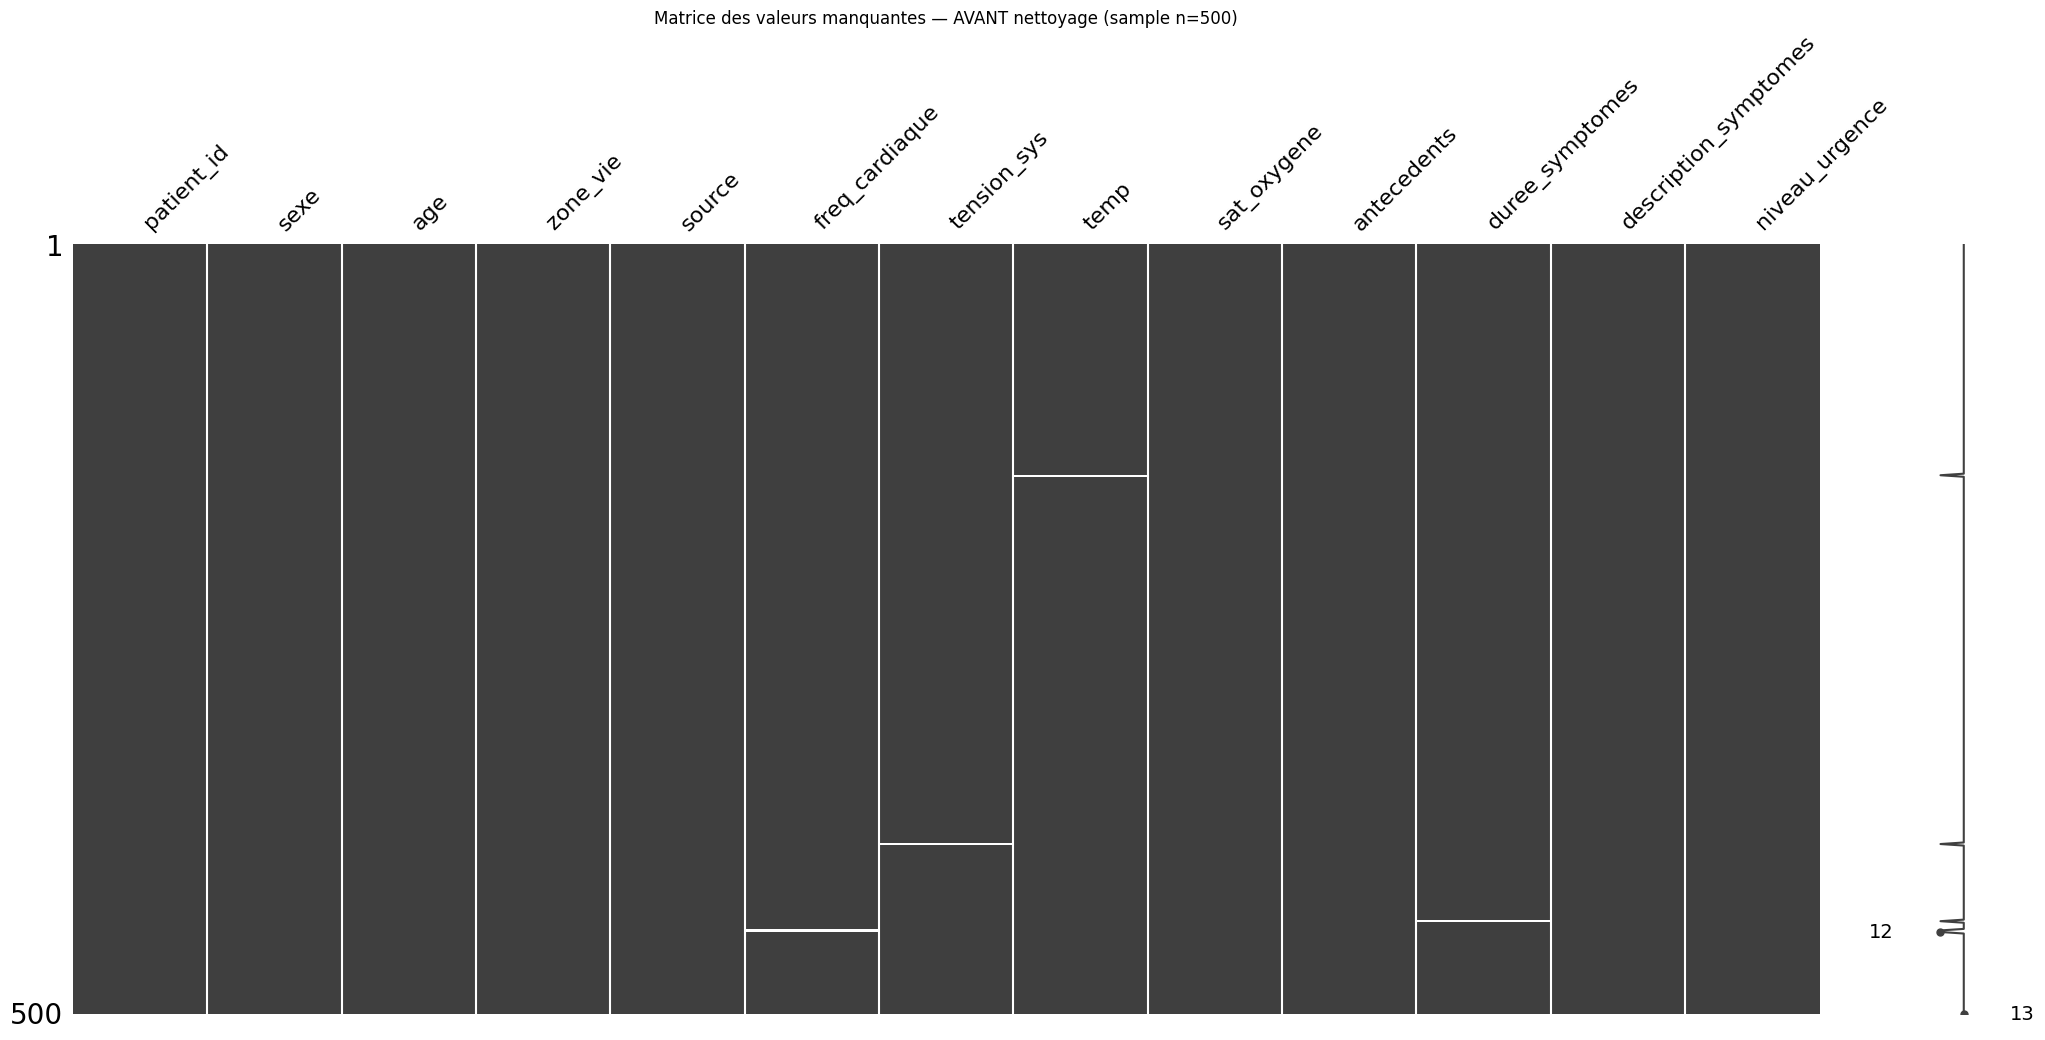

In [10]:
fig = plt.figure(figsize=(14, 6))
msno.matrix(df.sample(500, random_state=RANDOM_STATE))
plt.title('Matrice des valeurs manquantes — AVANT nettoyage (sample n=500)')
before_matrix_path = ARTIFACTS_DIR / 'missingno_matrix_before.png'
plt.savefig(before_matrix_path, bbox_inches='tight', dpi=200)
plt.show()


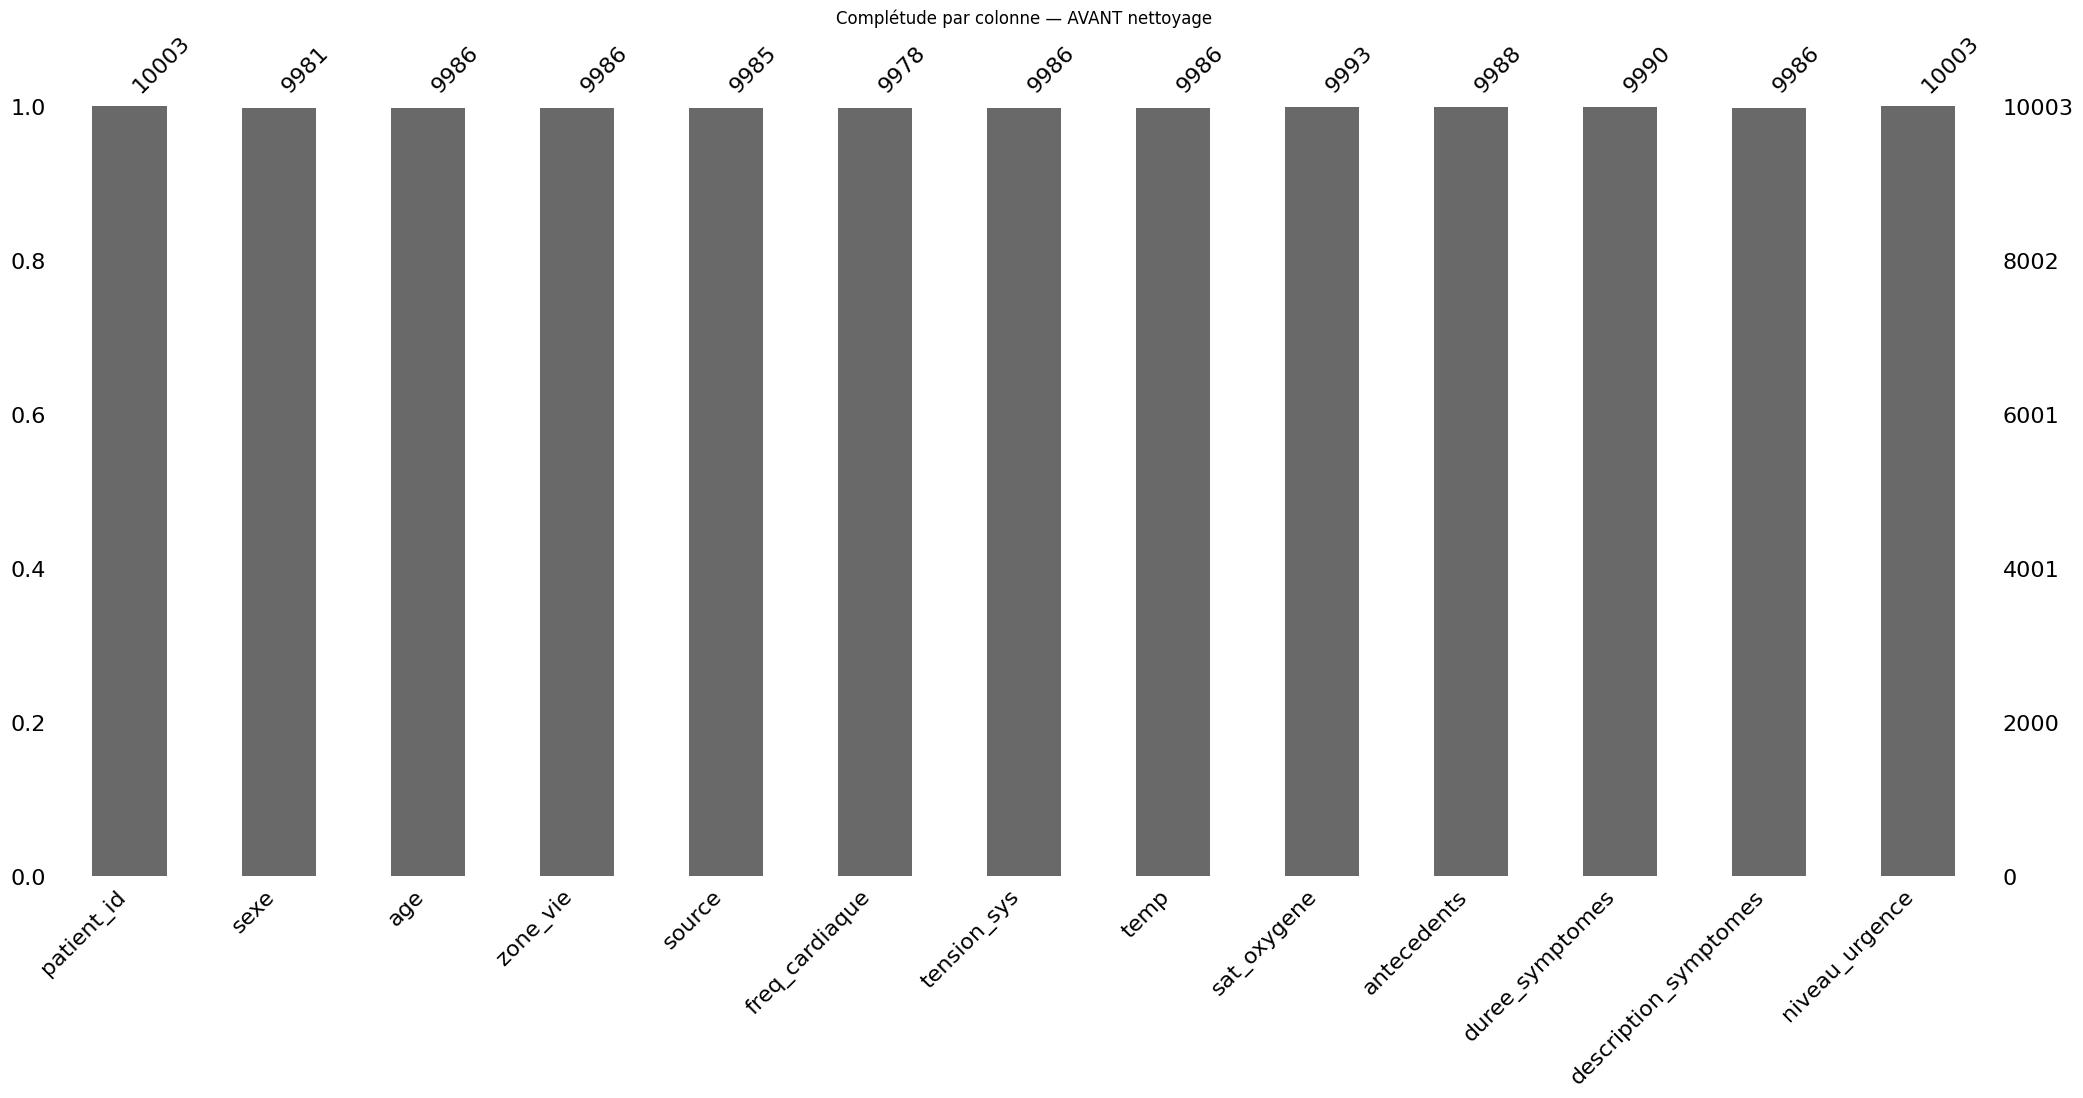

In [11]:
fig = plt.figure(figsize=(14, 4))
msno.bar(df)
plt.title('Complétude par colonne — AVANT nettoyage')
before_bar_path = ARTIFACTS_DIR / 'missingno_bar_before.png'
plt.savefig(before_bar_path, bbox_inches='tight', dpi=150)
plt.show()


## 4. Étape 1 — Identification des variables sensibles (Scénario 1 vs Scénario 2)

**Variables marquées comme sensibles :**
- `sexe` — potentiellement discriminante (risque de biais sexistes dans les prédictions médicales).
- `zone_vie` — urbain / rural peut devenir un proxy socio-économique.

**Approche conforme au PDF :** on **garde** ces colonnes dans le dataset processed et on les **liste** dans `SENSITIVE_COLS`. Au moment de l'entraînement, on construira deux jeux de features :
- **Scénario 1** (multimodal complet) : toutes les variables, y compris sensibles.
- **Scénario 2** (sans variables sensibles) : on retire `sexe` + `zone_vie`.

On entraînera chaque modèle sur les deux jeux pour pouvoir comparer l'impact des variables sensibles sur les performances (et donc justifier leur retrait ou leur conservation).

**Nuance médicale :** `sexe` a une vraie pertinence clinique (normes physiologiques différentes). La comparaison S1 vs S2 permettra de chiffrer le compromis biais ↔ pertinence.

In [12]:
SENSITIVE_COLS = ['sexe', 'zone_vie']
print(f'Variables sensibles marquées (conservées dans df) : {SENSITIVE_COLS}')
print(f'Colonnes courantes : {list(df.columns)}')


Variables sensibles marquées (conservées dans df) : ['sexe', 'zone_vie']
Colonnes courantes : ['patient_id', 'sexe', 'age', 'zone_vie', 'source', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes', 'description_symptomes', 'niveau_urgence']


## 5. Étape 2 — RGPD / données personnelles

**Variable concernée :** `patient_id` (identifiant unique du patient).

**Lecture du PDF :** le sujet demande de **traiter la conformité RGPD dans une section dédiée**, mais ne demande **pas** explicitement de retirer les identifiants personnels du dataset.

**Notre choix :** on **conserve `patient_id` dans le CSV processed** (utile pour la traçabilité, le journaling d'API, la levée d'identifiant en cas de réentraînement). On l'**exclura de la matrice de features** au moment de l'entraînement : un identifiant n'a aucun pouvoir prédictif et risquerait de provoquer du sur-apprentissage. C'est une nuance importante : la donnée est **stockée** mais pas **modélisée**.

Pour une vraie conformité RGPD on rajouterait : chiffrement at-rest, pseudonymisation, durée de conservation limitée, log d'accès, droit d'effacement.

In [13]:
print('patient_id conservé dans le dataset processed pour traçabilité,')
print('exclu de la matrice de features au moment du training.')
df.head(3)

patient_id conservé dans le dataset processed pour traçabilité,
exclu de la matrice de features au moment du training.


,patient_id,sexe,age,zone_vie,source,freq_cardiaque,tension_sys,temp,sat_oxygene,antecedents,duree_symptomes,description_symptomes,niveau_urgence
0,P0001,H,19.0,R,appel,110.4,128.6,37.8,93.8,0.0,62.2,Douleur abdominale aiguë localisée dans le qua...,1
1,P0002,H,56.0,U,appel,72.0,153.5,36.0,100.0,1.0,45.8,Demande de certificat médical pour une activit...,0
2,P0003,H,1.0,U,appel,70.4,117.7,36.9,97.6,0.0,8.0,Douleur dorsale chronique sans aggravation réc...,0


## 6. Étape 3 — Retrait des colonnes inexploitables (> 50 % NaN)

Une colonne avec plus de la moitié de ses valeurs manquantes ne peut pas être imputée correctement : on perdrait plus de signal qu'on n'en ajouterait. On les supprime systématiquement (rien dans ce dataset, mais la règle est appliquée par sécurité).

In [14]:
nan_ratio = df.isna().mean().sort_values(ascending=False)
print('Taux de NaN par colonne :')
print((nan_ratio * 100).round(2).astype(str) + ' %')

COLS_TOO_EMPTY = nan_ratio[nan_ratio > 0.5].index.tolist()
if COLS_TOO_EMPTY:
    print(f'\nColonnes > 50 % NaN supprimées : {COLS_TOO_EMPTY}')
    df = df.drop(columns=COLS_TOO_EMPTY)
else:
    print('\nAucune colonne > 50 % NaN — rien à supprimer.')

Taux de NaN par colonne :
freq_cardiaque           0.25 %
sexe                     0.22 %
source                   0.18 %
zone_vie                 0.17 %
age                      0.17 %
temp                     0.17 %
tension_sys              0.17 %
description_symptomes    0.17 %
antecedents              0.15 %
duree_symptomes          0.13 %
sat_oxygene               0.1 %
patient_id                0.0 %
niveau_urgence            0.0 %
dtype: object

Aucune colonne > 50 % NaN — rien à supprimer.


## 7. Étape 4 — Règles métiers : valeurs hors plage → NaN

On définit pour chaque variable numérique une **plage médicalement plausible**. Toute valeur en dehors est probablement une erreur de saisie ou un "troll" (ex. `age = 100000`) et est remplacée par `NaN`. Elles seront ré-imputées proprement plus tard par KNN.

| Variable | Plage admise | Justification |
|---|---|---|
| `age` | 0 – 120 ans | Durée de vie humaine maximale |
| `freq_cardiaque` | 30 – 250 bpm | Bradycardie sévère → tachycardie extrême |
| `tension_sys` | 60 – 250 mmHg | Hypotension extrême → urgence hypertensive |
| `temp` | 30 – 45 °C | Hypothermie sévère → hyperthermie extrême |
| `sat_oxygene` | 50 – 100 % | Borne physiologique |
| `duree_symptomes` | 0 – 720 h | 0 à 30 jours (au-delà → non pertinent en urgence) |
| `antecedents` | 0 ou 1 | Variable binaire |

In [15]:
business_rules = {
    'age': (0, 120),
    'freq_cardiaque': (30, 250),
    'tension_sys': (60, 250),
    'temp': (30, 45),
    'sat_oxygene': (50, 100),
    'duree_symptomes': (0, 720),
    'antecedents': (0, 1),
}

violations_report = {}
for col, (lo, hi) in business_rules.items():
    mask = (df[col] < lo) | (df[col] > hi)
    n_viol = int(mask.sum())
    violations_report[col] = n_viol
    df.loc[mask, col] = np.nan

print('Violations détectées (remplacées par NaN) :')
for col, n in violations_report.items():
    print(f'  {col:>18}: {n}')
print(f'\nTotal NaN dans le dataset après règles métiers : {df.isna().sum().sum()}')

Violations détectées (remplacées par NaN) :
                 age: 0
      freq_cardiaque: 0
         tension_sys: 0
                temp: 0
         sat_oxygene: 0
     duree_symptomes: 0
         antecedents: 0

Total NaN dans le dataset après règles métiers : 188


## 8. Étape 5 — Détection d'outliers IQR (⚠️ détectée mais **NON appliquée**)

L'**IQR (Interquartile Range)** repère les valeurs statistiquement extrêmes.

**Principe :**
1. Q1 (25e centile) et Q3 (75e centile).
2. IQR = Q3 − Q1.
3. Bornes : `[Q1 − 1.5 × IQR ; Q3 + 1.5 × IQR]` (1.5 = convention de Tukey).
4. Hors bornes = outlier.

**⚠️ Décision : on DÉTECTE mais on N'APPLIQUE PAS la suppression.**

En triage médical, une valeur extrême (saturation à 80 %, température à 41 °C) **n'est pas une erreur de saisie** : c'est **le signe même de l'urgence vitale** qu'on cherche à prédire. La preuve sur nos données — parmi les outliers IQR, la part de classe 2 (urgence vitale) :

| Vitale | outliers IQR | % qui sont classe 2 |
|---|---|---|
| `sat_oxygene` | 440 | **95.5 %** |
| `freq_cardiaque` | 170 | **93.5 %** |
| `tension_sys` | 353 | **92.4 %** |
| `temp` | 225 | **88.9 %** |

*(alors que la classe 2 ne pèse que **15 %** globalement)*

Les supprimer (puis les ré-imputer en « normal » par KNN) **effacerait le signal de la classe 2** et provoquerait du **sous-triage** — exactement l'erreur critique que le projet combat (ch. 19-20). Les vraies valeurs impossibles (ex. `age = 100000`) sont déjà gérées par les **règles métiers** (ch. 7). On **conserve** donc les vitales extrêmes.

In [16]:
# ⚠️ IQR : on DÉTECTE les outliers mais on NE LES SUPPRIME PAS (cf. markdown).
# En triage, les vitales extrêmes SONT le signal de l'urgence vitale (classe 2).
APPLIQUER_IQR = False

iqr_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'duree_symptomes']
print('Outliers IQR détectés (conservés) — part de classe 2 (urgence vitale) parmi eux :')
for col in iqr_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    mask = (df[col] < lo) | (df[col] > hi)
    n_out = int(mask.sum())
    pct2 = 100 * (df.loc[mask, 'niveau_urgence'] == 2).mean() if n_out else 0.0
    print(f'  {col:>16}: {n_out:>4} outliers | {pct2:5.1f}% sont des urgences vitales')
    if APPLIQUER_IQR:
        df.loc[mask, col] = np.nan

print(f'\nIQR appliqué : {APPLIQUER_IQR}  ->  signal des vitales extrêmes CONSERVÉ.')
print(f'NaN dans le dataset (inchangé par l IQR) : {df.isna().sum().sum()}')

Outliers IQR détectés (conservés) — part de classe 2 (urgence vitale) parmi eux :
               age:    0 outliers |   0.0% sont des urgences vitales
    freq_cardiaque:  170 outliers |  93.5% sont des urgences vitales
       tension_sys:  353 outliers |  92.4% sont des urgences vitales
              temp:  225 outliers |  88.9% sont des urgences vitales
       sat_oxygene:  440 outliers |  95.5% sont des urgences vitales
   duree_symptomes:    0 outliers |   0.0% sont des urgences vitales

IQR appliqué : False  ->  signal des vitales extrêmes CONSERVÉ.
NaN dans le dataset (inchangé par l IQR) : 188


## 9. Étape 6 — Suppression des lignes quasi-vides (garde-fou)

Une ligne où **la majorité des champs manquent** ne peut pas être imputée de façon fiable. Par sécurité, on supprime les lignes à **plus de 50 % de NaN**.

**Sur nos données : aucune ligne n'est dans ce cas** (au pire **1 valeur manquante sur 13**). Cette étape ne supprime donc rien ici — c'est un garde-fou qui protège le pipeline si les données changeaient.

Les 188 lignes à 1 NaN sont **conservées** : leur unique valeur manquante sera **imputée** à l'étape suivante (KNN), plutôt que supprimée. On préserve ainsi le maximum de données (et le signal de la classe 2).

In [17]:
# Garde-fou : on ne supprime que les lignes à PLUS de 50% de champs manquants.
# (ici aucune -> au pire 1 NaN sur 13 colonnes ; les NaN restants seront imputés par KNN)
n_now = len(df)
nan_frac = df.isna().mean(axis=1)            # fraction de NaN par ligne
rows_to_drop = df[nan_frac > 0.5].index
df = df.drop(index=rows_to_drop).reset_index(drop=True)

print(f'Lignes avant         : {n_now}')
print(f'Lignes > 50% NaN     : {len(rows_to_drop)} (supprimées)')
print(f'Lignes après         : {len(df)}')
print(f'NaN restants (-> KNN) : {df.isna().sum().sum()}')

Lignes avant         : 10003
Lignes > 50% NaN     : 0 (supprimées)
Lignes après         : 10003
NaN restants (-> KNN) : 188


## 10. Étape 7 — Imputation KNN

Pour combler les NaN restants on utilise **`KNNImputer`** : pour chaque cellule manquante, il regarde les **k plus proches voisins** (k = 5 par défaut) selon les autres colonnes numériques et impute la moyenne pondérée de leurs valeurs.

**Pourquoi KNN plutôt qu'une simple médiane ?**
- KNN exploite la **corrélation entre variables** (ex : âge ↔ tension). L'imputation est plus fidèle au profil de la ligne.
- Plus robuste qu'une moyenne globale qui écrase la diversité du dataset.

**Limitation :** KNN ne marche que sur des colonnes **numériques**. Pour les autres on traite séparément :
- `source` (catégorielle) : imputation par le **mode**.
- `antecedents` (binaire) : imputation par le **mode**.
- `description_symptomes` (texte) : on **supprime** les lignes au texte vide ou trop court — un récit clinique vide ne peut pas être inventé sans biaiser le modèle NLP.

**Important :** KNN repose sur des distances ; pour que toutes les colonnes pèsent autant on **standardise avant d'imputer**, puis on **dé-standardise** pour garder un CSV processed lisible (valeurs en unités physiologiques).

In [18]:
# Hygiène texte : suppression des lignes avec description vide ou NaN
n_pre_text = len(df)
df['description_symptomes'] = df['description_symptomes'].fillna('').astype(str).str.strip()
df = df[df['description_symptomes'].str.len() >= 5].reset_index(drop=True)
print(f'Lignes supprimées car description vide/trop courte : {n_pre_text - len(df)}')

# Imputation par le mode pour les catégorielles restantes
for col in ['source', 'antecedents', 'sexe', 'zone_vie']:
    n_missing = int(df[col].isna().sum())
    mode = df[col].mode(dropna=True).iloc[0]
    df[col] = df[col].fillna(mode)
    print(f'  Imputation mode {col!r:>18} ({n_missing} NaN) -> {mode!r}')

# Imputation KNN sur les numériques (sur données standardisées pour des distances équitables)
knn_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'duree_symptomes']
X_num = df[knn_cols].copy()
mu = X_num.mean()
sigma = X_num.std(ddof=1)
X_num_std = (X_num - mu) / sigma

imputer = KNNImputer(n_neighbors=5, weights='distance')
X_num_imputed_std = pd.DataFrame(
    imputer.fit_transform(X_num_std), columns=knn_cols, index=df.index
)
X_num_imputed = X_num_imputed_std * sigma + mu  # dé-standardisation
df[knn_cols] = X_num_imputed

print(f'\nNaN restants après imputation KNN : {df.isna().sum().sum()}')
print(f'Lignes finales : {len(df)}')

Lignes supprimées car description vide/trop courte : 17
  Imputation mode           'source' (18 NaN) -> 'appel'
  Imputation mode      'antecedents' (15 NaN) -> np.float64(1.0)
  Imputation mode             'sexe' (22 NaN) -> 'F'
  Imputation mode         'zone_vie' (17 NaN) -> 'U'

NaN restants après imputation KNN : 0
Lignes finales : 9986


## 11. Casting des types et normalisation légère du texte

In [19]:
df['age'] = df['age'].round().astype(int)
df['antecedents'] = df['antecedents'].round().astype(int)
df['niveau_urgence'] = df['niveau_urgence'].astype(int)
df['source'] = df['source'].astype('category')
df.dtypes

patient_id                 object
sexe                       object
age                         int64
zone_vie                   object
source                   category
freq_cardiaque            float64
tension_sys               float64
temp                      float64
sat_oxygene               float64
antecedents                 int64
duree_symptomes           float64
description_symptomes      object
niveau_urgence              int64
dtype: object

## 12. Visualisation des valeurs manquantes — APRÈS nettoyage

<Figure size 1400x600 with 0 Axes>

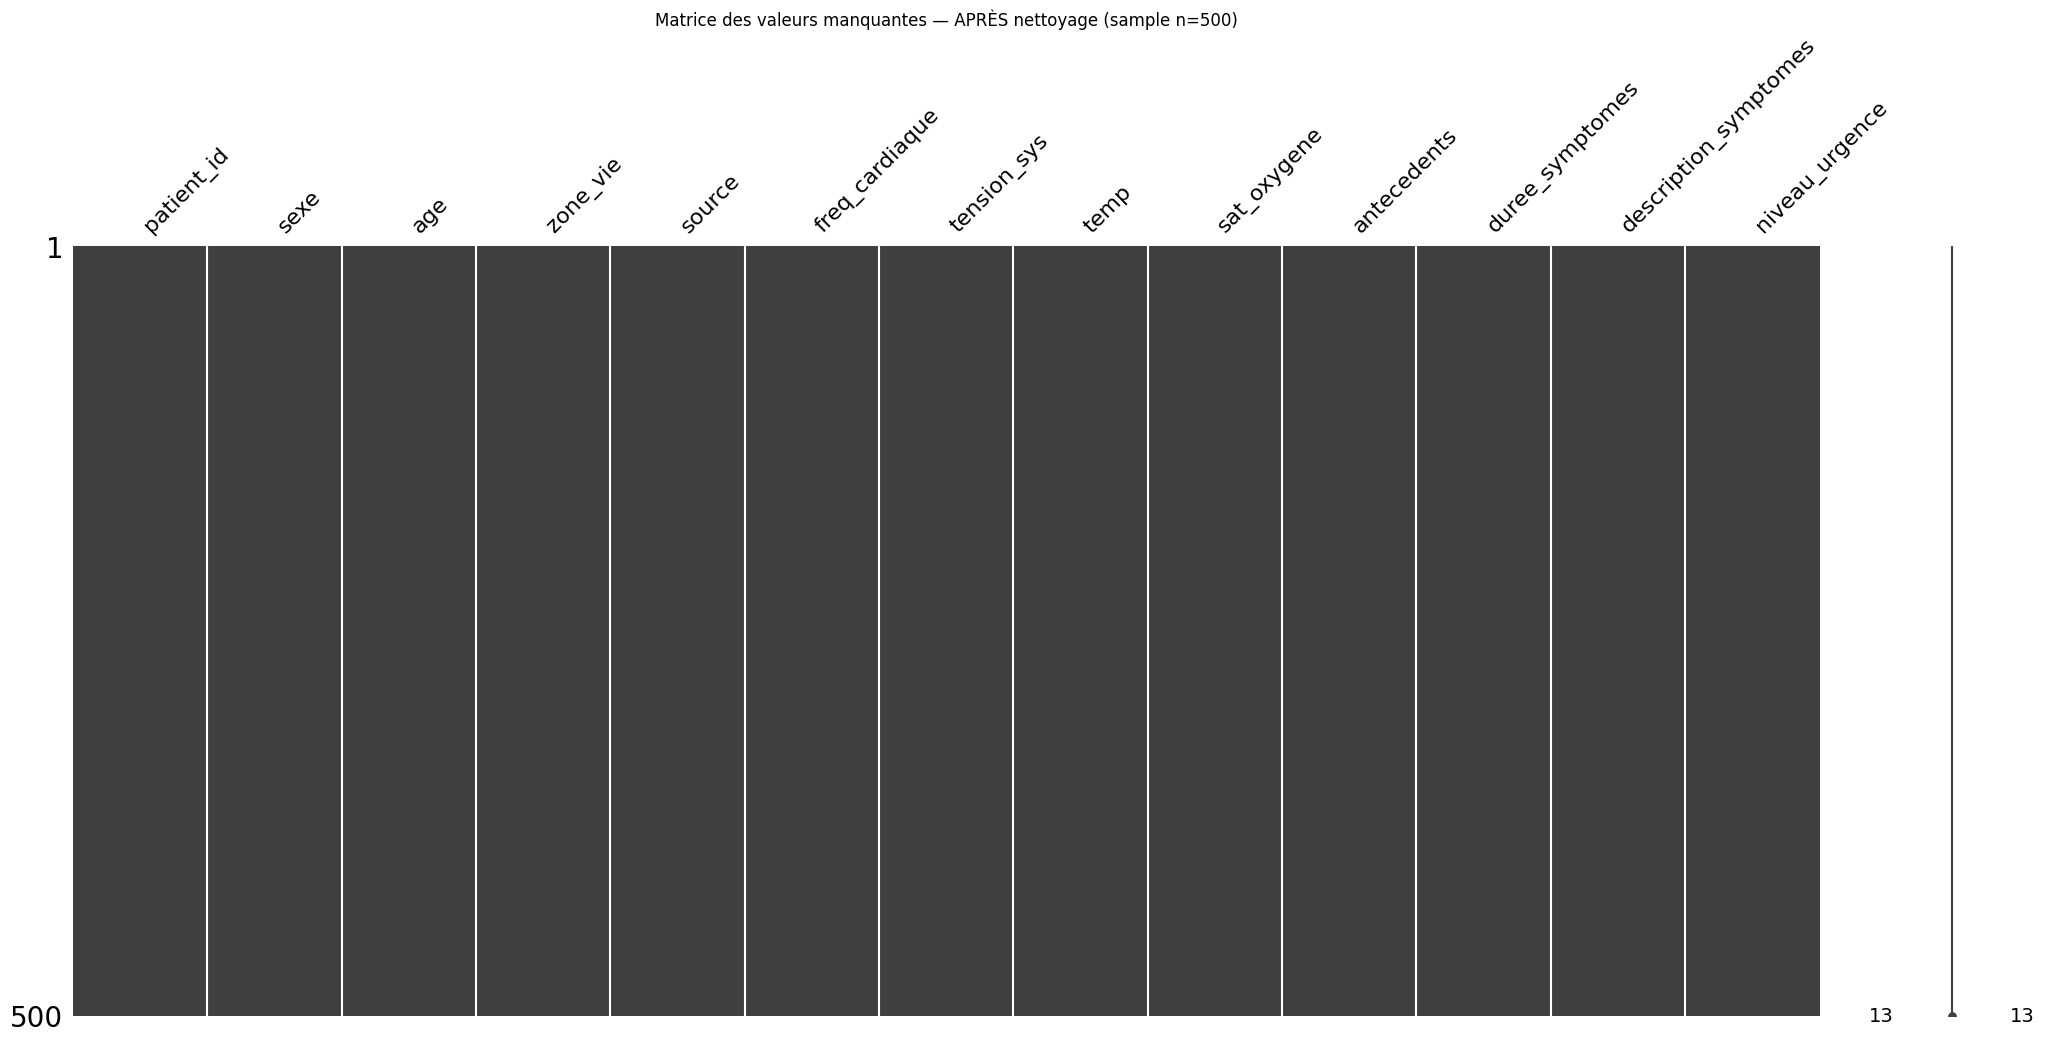

In [20]:
fig = plt.figure(figsize=(14, 6))
msno.matrix(df.sample(500, random_state=RANDOM_STATE))
plt.title('Matrice des valeurs manquantes — APRÈS nettoyage (sample n=500)')
after_matrix_path = ARTIFACTS_DIR / 'missingno_matrix_after.png'
plt.savefig(after_matrix_path, bbox_inches='tight', dpi=200)
plt.show()

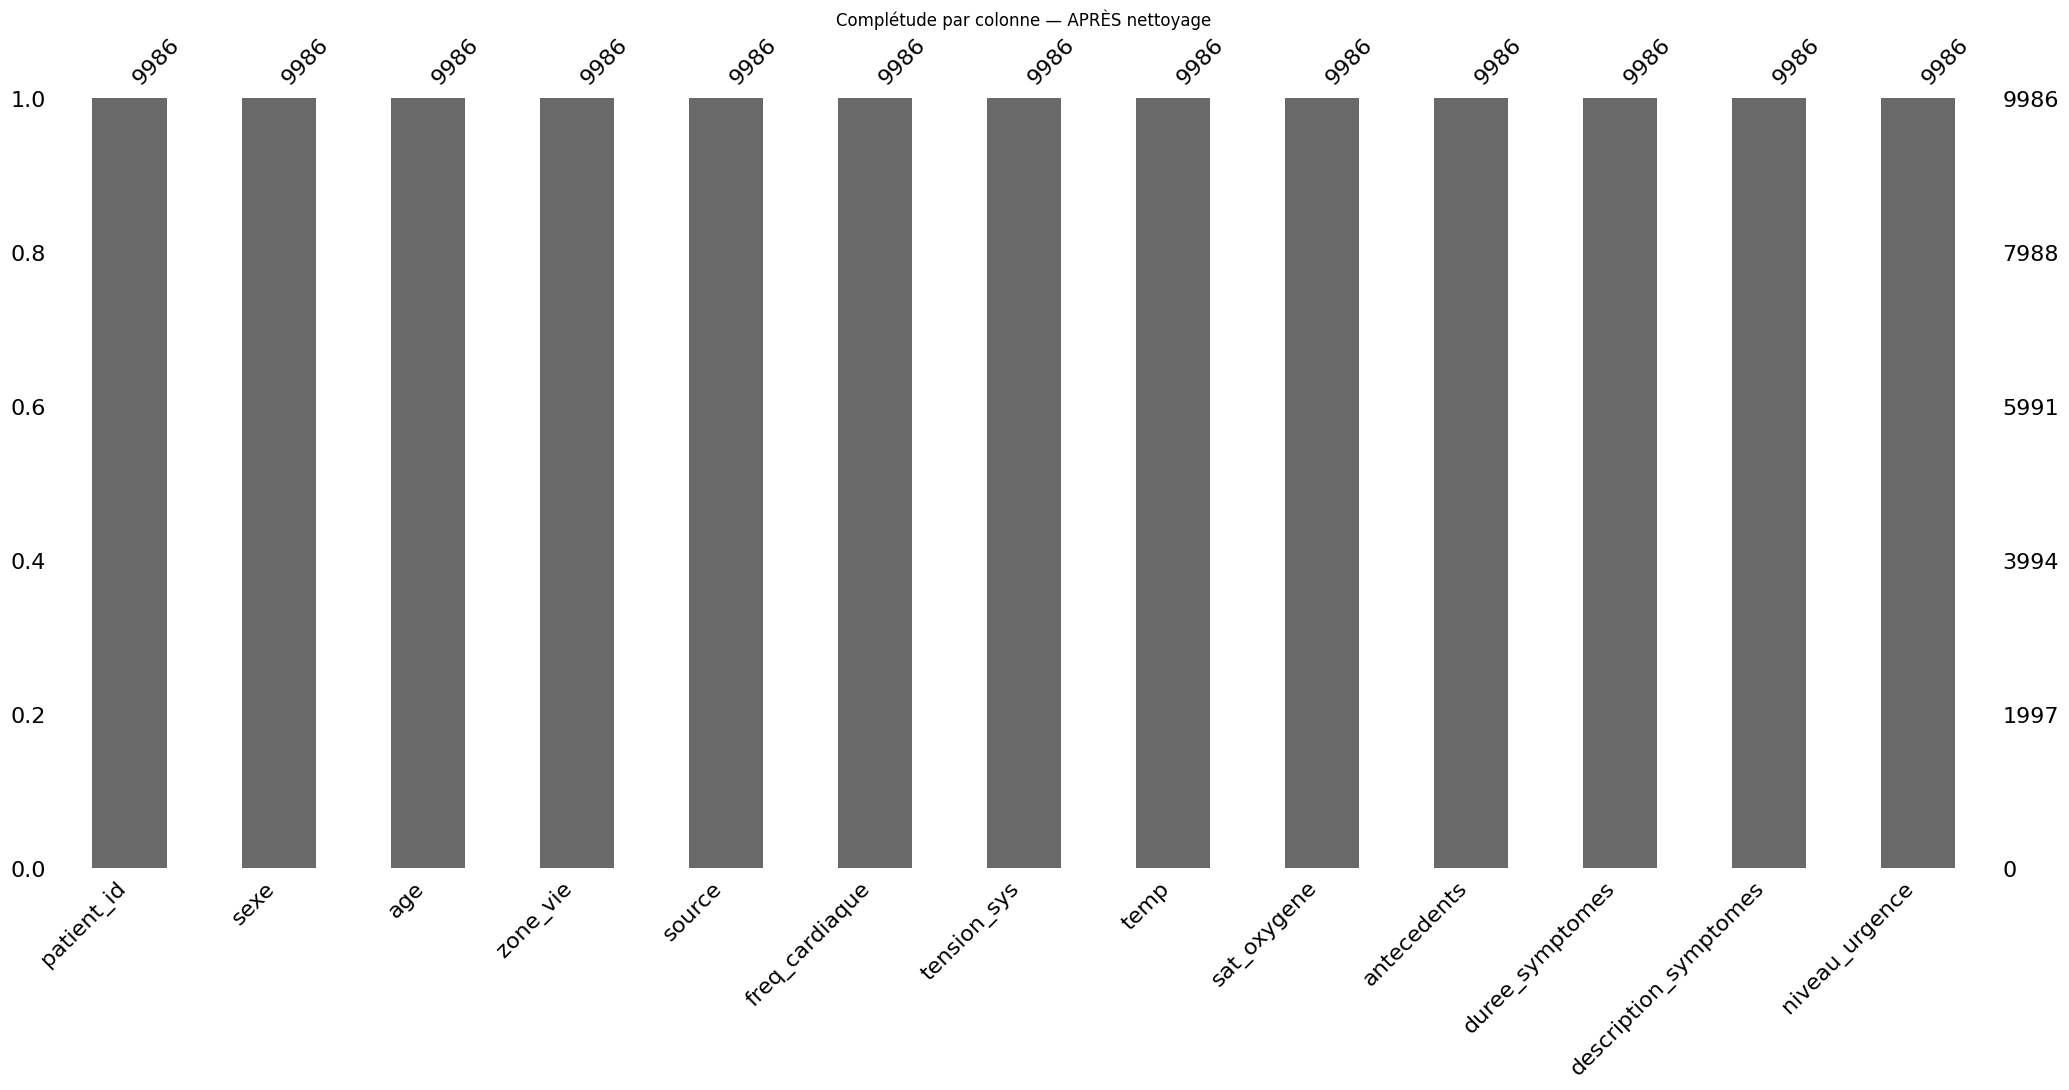

In [21]:
fig = plt.figure(figsize=(14, 4))
msno.bar(df)
plt.title('Complétude par colonne — APRÈS nettoyage')
after_bar_path = ARTIFACTS_DIR / 'missingno_bar_after.png'
plt.savefig(after_bar_path, bbox_inches='tight', dpi=150)
plt.show()

## 13. Sauvegarde du dataset processed

In [22]:
df.to_csv(PROCESSED_PATH, index=False)
print('Écrit :', PROCESSED_PATH)
print('Shape :', df.shape)


Écrit : /Users/sebastien/Certification-Atlas-CISIA/data/processed/dataset_telemed_processed.csv
Shape : (9986, 13)


## 14. Feature engineering — standardisation, normalisation, encodage, TF-IDF

On construit la matrice de features complète (toutes les variables, y compris sensibles). Le retrait éventuel des variables sensibles se fait juste avant l'entraînement, ce qui permet de comparer **Scénario 1** (toutes variables) et **Scénario 2** (sans `sexe` + `zone_vie`) sans refaire tout le pré-traitement.

**Choix par variable :**

| Variable | Méthode | Justification |
|---|---|---|
| `age`, `freq_cardiaque`, `tension_sys`, `temp`, `duree_symptomes` | **Standardisation** (z-score, ddof = 1) | Échelles très différentes. La standardisation amène moyenne = 0, écart-type = 1 sans déformer la forme. Indispensable pour le MLP, utile (sans être obligatoire) pour les arbres. |
| `sat_oxygene` | **Normalisation min-max → [0, 1]** | Variable physiologiquement **bornée** (50 – 100 %). Le min-max conserve l'interprétation de "distance au plancher de saturation". |
| `antecedents` | aucune | Binaire 0/1, déjà sur [0, 1]. |
| `source`, `sexe`, `zone_vie` | **Binaire 0/1** | Toutes à 2 modalités → simple flag 0/1 (one-hot inutile). |
| `description_symptomes` | **TF-IDF** (200 features, bigrammes) | Vectorisation du texte ; pondère les mots informatifs. |
| `patient_id` | exclu de la matrice de features | Identifiant sans valeur prédictive (cf. note RGPD). |

**Pourquoi `ddof = 1` (n − 1) pour la standardisation ?**
On travaille sur un **échantillon** et non sur la **population** complète. La formule d'écart-type non biaisé est :

$$ s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2} $$

Diviser par n (ddof = 0, défaut de `StandardScaler`) sous-estime légèrement la variance ; avec n − 1 on a un estimateur **non biaisé**.

**Pas de fuite de données :** moyennes, écart-types, min, max et vocabulaire TF-IDF sont calculés **uniquement sur le train**.

In [23]:
FEATURE_COLS_NUM_STD = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'duree_symptomes']
FEATURE_COL_MMS = 'sat_oxygene'
FEATURE_COL_TEXT = 'description_symptomes'
TARGET = 'niveau_urgence'

X_full = df.drop(columns=[TARGET, 'patient_id'])
y = df[TARGET].values

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train :', X_train_df.shape, '| classes :', np.bincount(y_train))
print('Test  :', X_test_df.shape, '| classes :', np.bincount(y_test))

Train : (7988, 11) | classes : [4006 2817 1165]
Test  : (1998, 11) | classes : [1002  705  291]


In [ ]:
# prétraitement en pipeline (refit par pli) pour éviter le data leak en cv
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

NUM_STD_COLS = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'duree_symptomes']
NUM_MMS_COLS = ['sat_oxygene']
BIN_CAT_COLS = ['source', 'sexe', 'zone_vie']
TEXT_COL     = 'description_symptomes'
SENSITIVE_COLS_FEAT = ['sexe', 'zone_vie']

SCENARIOS = ['S1', 'S2', 'S3', 'S4']
SCENARIO_LABELS = {
    'S1': 'S1 — Multimodal complet',
    'S2': 'S2 — Sans variables sensibles',
    'S3': 'S3 — NLP seul (texte)',
    'S4': 'S4 — Tabulaire seul',
}

# Stop-words FR (mots de liaison) : sklearn n'a pas de liste FR intégrée.
# Liste inline -> pas de dépendance (nltk/spacy absents de l'env).
FRENCH_STOP_WORDS = [
    'au', 'aux', 'avec', 'après', 'ce', 'ces', 'dans', 'de', 'des', 'du', 'elle', 'en',
    'et', 'eux', 'il', 'ils', 'je', 'la', 'le', 'les', 'leur', 'lui', 'ma',
    'mais', 'me', 'meme', 'mes', 'moi', 'mon', 'ne', 'nos', 'notre', 'nous',
    'on', 'ou', 'par', 'pas', 'pour', 'qu', 'que', 'qui', 'sa', 'se', 'ses',
    'son', 'sur', 'ta', 'te', 'tes', 'toi', 'ton', 'tu', 'un', 'une', 'vos',
    'votre', 'vous', 'ceci', 'cela', 'celui', 'donc', 'plus', 'sans', 'sous',
    'depuis', 'chez', 'entre', 'vers', 'comme', 'aussi', 'est', 'etre', 'a',
    'ont', 'ete', 'son', 'les', 'd', 'l', 's', 'n', 'c', 'j', 'y',
]

def build_preprocessor(scenario):
    # prétraitement du scénario (mêmes lignes train/test partout)
    include_text = scenario in ('S1', 'S2', 'S3')   # S3 = texte seul
    include_tab  = scenario in ('S1', 'S2', 'S4')    # S4 = tabulaire seul
    bin_cat = [c for c in BIN_CAT_COLS
               if not (scenario == 'S2' and c in SENSITIVE_COLS_FEAT)]
    transformers = []
    if include_tab:
        transformers += [
            ('num_std', StandardScaler(), NUM_STD_COLS),
            ('num_mms', MinMaxScaler(), NUM_MMS_COLS),
            ('antecedents', 'passthrough', ['antecedents']),
            ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), bin_cat),
        ]
    if include_text:
        transformers += [
            ('txt', TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=2, max_df=0.8, stop_words=FRENCH_STOP_WORDS), TEXT_COL),
        ]
    return ColumnTransformer(transformers)

print('Nombre de features par scénario :')
for s in SCENARIOS:
    n = build_preprocessor(s).fit_transform(X_train_df, y_train).shape[1]
    print(f'  {s}  {SCENARIO_LABELS[s]:32} -> {n:3d} features')

# # Standardisation ddof=1 (fit sur train uniquement)
# mu_train = X_train_df[FEATURE_COLS_NUM_STD].mean()
# sigma_train = X_train_df[FEATURE_COLS_NUM_STD].std(ddof=1)
# X_train_num_std = (X_train_df[FEATURE_COLS_NUM_STD] - mu_train) / sigma_train
# X_test_num_std = (X_test_df[FEATURE_COLS_NUM_STD] - mu_train) / sigma_train
#
# # MinMax sur sat_oxygene (fit sur train)
# mn, mx = X_train_df[FEATURE_COL_MMS].min(), X_train_df[FEATURE_COL_MMS].max()
# X_train_mms = ((X_train_df[FEATURE_COL_MMS] - mn) / (mx - mn)).to_frame()
# X_test_mms = ((X_test_df[FEATURE_COL_MMS] - mn) / (mx - mn)).to_frame().clip(0, 1)
#
# # Variables binaires -> booléen True/False, une règle EXPLICITE par colonne.
# # antecedents est déjà 0/1 -> converti en booléen pour rester homogène.
# X_train_bin = pd.DataFrame({
#     'antecedents': X_train_df['antecedents'].astype(bool),
#     'source':   (X_train_df['source']   == 'chat'),
#     'sexe':     (X_train_df['sexe']     == 'H'),
#     'zone_vie': (X_train_df['zone_vie'] == 'U'),
# }, index=X_train_df.index)
# X_test_bin = pd.DataFrame({
#     'antecedents': X_test_df['antecedents'].astype(bool),
#     'source':   (X_test_df['source']   == 'chat'),
#     'sexe':     (X_test_df['sexe']     == 'H'),
#     'zone_vie': (X_test_df['zone_vie'] == 'U'),
# }, index=X_test_df.index)
#
# # TF-IDF sur la description (fit sur train)
# tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=2)
# X_train_txt = tfidf.fit_transform(X_train_df[FEATURE_COL_TEXT]).toarray()
# X_test_txt = tfidf.transform(X_test_df[FEATURE_COL_TEXT]).toarray()
# txt_feature_names = [f'tfidf__{w}' for w in tfidf.get_feature_names_out()]
# X_train_txt = pd.DataFrame(X_train_txt, columns=txt_feature_names, index=X_train_df.index)
# X_test_txt = pd.DataFrame(X_test_txt, columns=txt_feature_names, index=X_test_df.index)
#
# # Matrice complète (Scénario 1)
# X_train = pd.concat([X_train_num_std, X_train_mms, X_train_bin, X_train_txt], axis=1)
# X_test = pd.concat([X_test_num_std, X_test_mms, X_test_bin, X_test_txt], axis=1)
#
# # Colonnes sensibles : désormais des colonnes binaires nommées directement
# sensitive_feature_cols = list(SENSITIVE_COLS)  # colonnes binaires nommées directement
# print('Colonnes sensibles dans la matrice features :', sensitive_feature_cols)
# print()
# print('Matrice complète (Scénario 1) :')
# print('  X_train :', X_train.shape)
# print('  X_test  :', X_test.shape)
# X_train.head()


Nombre de features par scénario :
  S1  S1 — Multimodal complet          -> 210 features
  S2  S2 — Sans variables sensibles    -> 208 features
  S3  S3 — NLP seul (texte)            -> 200 features
  S4  S4 — Tabulaire seul              ->  10 features


## 15. Validation croisée K-Fold stratifiée

**Pourquoi K-Fold ?** Un seul split train / test donne une estimation unique ; en répétant k fois (k = 5) on obtient une mesure plus robuste de la performance et de sa variance.

**Pourquoi stratifié ?** Les classes sont déséquilibrées (≈ 50 % / 35 % / 15 %). Sans stratification, certains plis pourraient sous-représenter la classe "urgence vitale".

On définit une instance `StratifiedKFold` réutilisée pour tous les modèles.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Schéma : StratifiedKFold(n_splits=5, shuffle=True)')
print('Métriques cibles (PDF) : accuracy + F1 pondéré + matrice de confusion')

Schéma : StratifiedKFold(n_splits=5, shuffle=True)
Métriques cibles (PDF) : accuracy + F1 pondéré + matrice de confusion


## 16. Entraînement des modèles + validation croisée

On compare **4 familles de modèles distinctes** sur **chacun des 4 scénarios** du PDF
(soit une grille **4 modèles × 4 scénarios = 16 entraînements**) :

| Modèle | Famille |
|---|---|
| **LogReg** (régression logistique) | linéaire — baseline |
| **RandomForest** | bagging d'arbres |
| **LightGBM** | boosting d'arbres |
| **MLP** | réseau de neurones |

Pour chaque couple (modèle × scénario) :
1. CV 5-fold stratifiée sur le train → moyenne ± écart-type.
2. Entraînement final sur tout le train.
3. Évaluation sur le test (accuracy, F1 pondéré, matrice de confusion).
4. Un run MLflow taggué `model` + `scenario`.

> Les features numériques sont déjà standardisées en amont (cellule 14), ce qui
> bénéficie à **LogReg** et au **MLP** ; c'est sans effet sur les arbres
> (RandomForest, LightGBM), qui y sont insensibles.


In [26]:
# 4 modèles + évaluation via pipeline (cv sans fuite)
MODELS = ['LogReg', 'RandomForest', 'LightGBM', 'MLP']

def cree_modele(nom):
    if nom == 'LogReg':
        return LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
        )
    if nom == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=300, max_depth=12, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=1,  # la cv parallélise déjà les plis
        )
    if nom == 'LightGBM':
        return LGBMClassifier(
            n_estimators=200, num_leaves=15, learning_rate=0.05,
            min_child_samples=60, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            objective='multiclass', num_class=3, class_weight='balanced',
            importance_type='gain',  # feature importance = contribution réelle (pas nb de splits)
            random_state=RANDOM_STATE, n_jobs=1, verbose=-1,
        )
    if nom == 'MLP':
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), activation='relu',
            learning_rate_init=1e-3, max_iter=80,
            early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f'modèle inconnu : {nom}')

def make_pipeline(scenario, model_name):
    return Pipeline([
        ('prep', build_preprocessor(scenario)),
        ('model', cree_modele(model_name)),
    ])

def evaluate_model(name, scenario_tag, X_train_df, X_test_df, y_train, y_test, cv, suffix=''):
    cv_res = cross_validate(make_pipeline(scenario_tag, name), X_train_df, y_train,
                            cv=cv, scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
    cv_acc = cv_res['test_accuracy']
    cv_f1  = cv_res['test_f1_weighted']

    pipe = make_pipeline(scenario_tag, name)
    pipe.fit(X_train_df, y_train)
    y_pred = pipe.predict(X_test_df)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    n_features = len(pipe.named_steps['prep'].get_feature_names_out())

    print(f'\n=== {name} [{scenario_tag}] ===')
    print(f'CV  accuracy    : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
    print(f'CV  F1 pondéré  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
    print(f'Test accuracy   : {test_acc:.4f}')
    print(f'Test F1 pondéré : {test_f1:.4f}')

    with mlflow.start_run(run_name=f'model_{name}_{scenario_tag}{suffix}'):
        mlflow.set_tag('dataset', 'iqr' if suffix else 'baseline')
        mlflow.set_tag('stage', 'modeling')
        mlflow.set_tag('model', name)
        mlflow.set_tag('scenario', scenario_tag)
        mlflow.log_params(pipe.named_steps['model'].get_params())
        mlflow.log_param('n_features', n_features)
        mlflow.log_metric('cv_accuracy_mean', float(cv_acc.mean()))
        mlflow.log_metric('cv_accuracy_std', float(cv_acc.std()))
        mlflow.log_metric('cv_f1_weighted_mean', float(cv_f1.mean()))
        mlflow.log_metric('cv_f1_weighted_std', float(cv_f1.std()))
        mlflow.log_metric('test_accuracy', float(test_acc))
        mlflow.log_metric('test_f1_weighted', float(test_f1))

    return {
        'name': name, 'scenario': scenario_tag, 'model': pipe,
        'cv_acc_mean': cv_acc.mean(), 'cv_acc_std': cv_acc.std(),
        'cv_f1_mean': cv_f1.mean(), 'cv_f1_std': cv_f1.std(),
        'test_acc': test_acc, 'test_f1': test_f1,
        'cm': cm, 'y_pred': y_pred,
    }

results = {}  # results[scénario][modèle]

# ancien code manuel (référence) :
# def evaluate_model(name, X_train, X_test, y_train, y_test, cv, scenario_tag):
#     """CV + fit + eval test + run MLflow taggué par scénario. Retourne un dict."""
#     # On reconstruit un modèle vierge à chaque appel pour éviter de partager l'état entre scénarios.
#     model = cree_modele(name)
#     cv_res = cross_validate(model, X_train, y_train, cv=cv,
#                             scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
#     cv_acc = cv_res['test_accuracy']
#     cv_f1  = cv_res['test_f1_weighted']
#
#     model = cree_modele(name)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     test_acc = accuracy_score(y_test, y_pred)
#     test_f1  = f1_score(y_test, y_pred, average='weighted')
#     cm = confusion_matrix(y_test, y_pred)
#
#     print(f'\n=== {name} [{scenario_tag}] ===')
#     print(f'CV  accuracy    : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
#     print(f'CV  F1 pondéré  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
#     print(f'Test accuracy   : {test_acc:.4f}')
#     print(f'Test F1 pondéré : {test_f1:.4f}')
#
#     with mlflow.start_run(run_name=f'model_{name}_{scenario_tag}'):
#         mlflow.set_tag('stage', 'modeling')
#         mlflow.set_tag('model', name)
#         mlflow.set_tag('scenario', scenario_tag)
#         mlflow.log_params(model.get_params())
#         mlflow.log_param('n_features', X_train.shape[1])
#         mlflow.log_metric('cv_accuracy_mean', float(cv_acc.mean()))
#         mlflow.log_metric('cv_accuracy_std', float(cv_acc.std()))
#         mlflow.log_metric('cv_f1_weighted_mean', float(cv_f1.mean()))
#         mlflow.log_metric('cv_f1_weighted_std', float(cv_f1.std()))
#         mlflow.log_metric('test_accuracy', float(test_acc))
#         mlflow.log_metric('test_f1_weighted', float(test_f1))
#
#     return {
#         'name': name, 'scenario': scenario_tag, 'model': model,
#         'cv_acc_mean': cv_acc.mean(), 'cv_acc_std': cv_acc.std(),
#         'cv_f1_mean': cv_f1.mean(), 'cv_f1_std': cv_f1.std(),
#         'test_acc': test_acc, 'test_f1': test_f1,
#         'cm': cm, 'y_pred': y_pred,
#     }
#
#
# # ============================================================================
# #  LES 4 JEUX DE DONNÉES — UN PAR SCÉNARIO DU PDF
# #  Mêmes lignes train/test partout : on ne change QUE les COLONNES (features)
# #  données au modèle. Chaque dataset porte un nom explicite pour s'y retrouver.
# # ============================================================================
# tfidf_cols   = [c for c in X_train.columns if c.startswith('tfidf__')]   # récit clinique vectorisé (texte)
# tabular_cols = [c for c in X_train.columns if c not in tfidf_cols]        # tout sauf le texte
#
# # --- Scénario 1 — MULTIMODAL COMPLET : tabulaire + texte, variables sensibles incluses ---
# X_train_S1_multimodal      = X_train.copy()
# X_test_S1_multimodal       = X_test.copy()
#
# # --- Scénario 2 — SANS VARIABLES SENSIBLES : on retire sexe + zone_vie (RGPD / anti-biais) ---
# X_train_S2_sans_sensibles  = X_train.drop(columns=sensitive_feature_cols)
# X_test_S2_sans_sensibles   = X_test.drop(columns=sensitive_feature_cols)
#
# # --- Scénario 3 — NLP SEUL : uniquement le récit clinique (TF-IDF), aucune donnée tabulaire ---
# X_train_S3_nlp_seul        = X_train[tfidf_cols]
# X_test_S3_nlp_seul         = X_test[tfidf_cols]
#
# # --- Scénario 4 — TABULAIRE SEUL : constantes vitales + âge + admin, sans le texte ---
# X_train_S4_tabulaire_seul  = X_train[tabular_cols]
# X_test_S4_tabulaire_seul   = X_test[tabular_cols]
#
# # Libellés lisibles, réutilisés dans les graphes et le récapitulatif
# SCENARIO_LABELS = {
#     'S1': 'S1 — Multimodal complet',
#     'S2': 'S2 — Sans variables sensibles',
#     'S3': 'S3 — NLP seul (texte)',
#     'S4': 'S4 — Tabulaire seul',
# }
#
# # Dict scénario -> (X_train, X_test) consommé par la boucle d'entraînement
# scenarios = {
#     'S1': (X_train_S1_multimodal,     X_test_S1_multimodal),
#     'S2': (X_train_S2_sans_sensibles, X_test_S2_sans_sensibles),
#     'S3': (X_train_S3_nlp_seul,       X_test_S3_nlp_seul),
#     'S4': (X_train_S4_tabulaire_seul, X_test_S4_tabulaire_seul),
# }
#
# print('Jeux de données par scénario :')
# for tag, (X_tr, _) in scenarios.items():
#     print(f'  {tag}  {SCENARIO_LABELS[tag]:32} -> {X_tr.shape[1]:3d} features | {X_tr.shape[0]} lignes train')
#
# # ============================================================================
# #  LES 4 MODÈLES — 4 familles distinctes : linéaire / bagging / boosting / réseau.
# #  cree_modele(nom) renvoie un modèle NEUF à chaque appel : un modèle sklearn garde
# #  son état après .fit(), on en recrée donc un vierge pour chaque scénario.
# # ============================================================================
# MODELS = ['LogReg', 'RandomForest', 'LightGBM', 'MLP']
#
# def cree_modele(nom):
#     if nom == 'LogReg':
#         return LogisticRegression(
#             max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
#         )
#     if nom == 'RandomForest':
#         return RandomForestClassifier(
#             n_estimators=300, max_depth=12, class_weight='balanced',
#             random_state=RANDOM_STATE, n_jobs=1,  # la cv parallélise déjà les plis (évite la sur-souscription)
#         )
#     if nom == 'LightGBM':
#         return LGBMClassifier(
#             n_estimators=200, num_leaves=15, learning_rate=0.05,
#             min_child_samples=60, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
#             objective='multiclass', num_class=3, class_weight='balanced',
#             random_state=RANDOM_STATE, n_jobs=1, verbose=-1,  # idem
#         )
#     if nom == 'MLP':
#         return MLPClassifier(
#             hidden_layer_sizes=(128, 64), activation='relu',
#             learning_rate_init=1e-3, max_iter=80,
#             early_stopping=True, validation_fraction=0.1,
#             random_state=RANDOM_STATE,
#         )
#     raise ValueError(f'modèle inconnu : {nom}')
#
# results = {}  # results[scénario][modèle]


In [27]:
for scenario_tag in SCENARIOS:
    results[scenario_tag] = {}
    for model_name in MODELS:
        results[scenario_tag][model_name] = evaluate_model(
            model_name, scenario_tag, X_train_df, X_test_df, y_train, y_test, cv
        )



=== LogReg [S1] ===
CV  accuracy    : 0.9328 ± 0.0082
CV  F1 pondéré  : 0.9332 ± 0.0082
Test accuracy   : 0.9239
Test F1 pondéré : 0.9245

=== RandomForest [S1] ===
CV  accuracy    : 0.9329 ± 0.0084
CV  F1 pondéré  : 0.9331 ± 0.0083
Test accuracy   : 0.9279
Test F1 pondéré : 0.9285

=== LightGBM [S1] ===
CV  accuracy    : 0.9462 ± 0.0033
CV  F1 pondéré  : 0.9463 ± 0.0034
Test accuracy   : 0.9439
Test F1 pondéré : 0.9444

=== MLP [S1] ===
CV  accuracy    : 0.9325 ± 0.0068
CV  F1 pondéré  : 0.9322 ± 0.0068
Test accuracy   : 0.9319
Test F1 pondéré : 0.9317

=== LogReg [S2] ===
CV  accuracy    : 0.9336 ± 0.0068
CV  F1 pondéré  : 0.9341 ± 0.0068
Test accuracy   : 0.9249
Test F1 pondéré : 0.9255

=== RandomForest [S2] ===
CV  accuracy    : 0.9329 ± 0.0068
CV  F1 pondéré  : 0.9331 ± 0.0067
Test accuracy   : 0.9324
Test F1 pondéré : 0.9328

=== LightGBM [S2] ===
CV  accuracy    : 0.9458 ± 0.0019
CV  F1 pondéré  : 0.9459 ± 0.0021
Test accuracy   : 0.9474
Test F1 pondéré : 0.9478

=== MLP [S2] 

## 17. Courbes — matrices de confusion, ROC, learning curves

**Matrice de confusion** : le nombre d'échantillons pour chaque couple (vrai label, label prédit). Pour notre métier, **la diagonale doit être maximale**, et surtout **les cases en bas à gauche** (urgence vitale classée non urgente / relative) **doivent être minimales** — ce sont les erreurs critiques pointées par le PDF.

**ROC + AUC** : en multi-classes on trace une ROC par classe en one-vs-rest. L'AUC quantifie la séparation entre cette classe et les autres.

**Learning curve** : performance train vs validation selon le nombre d'exemples. Permet de voir si le modèle sous-apprend ou sur-apprend.

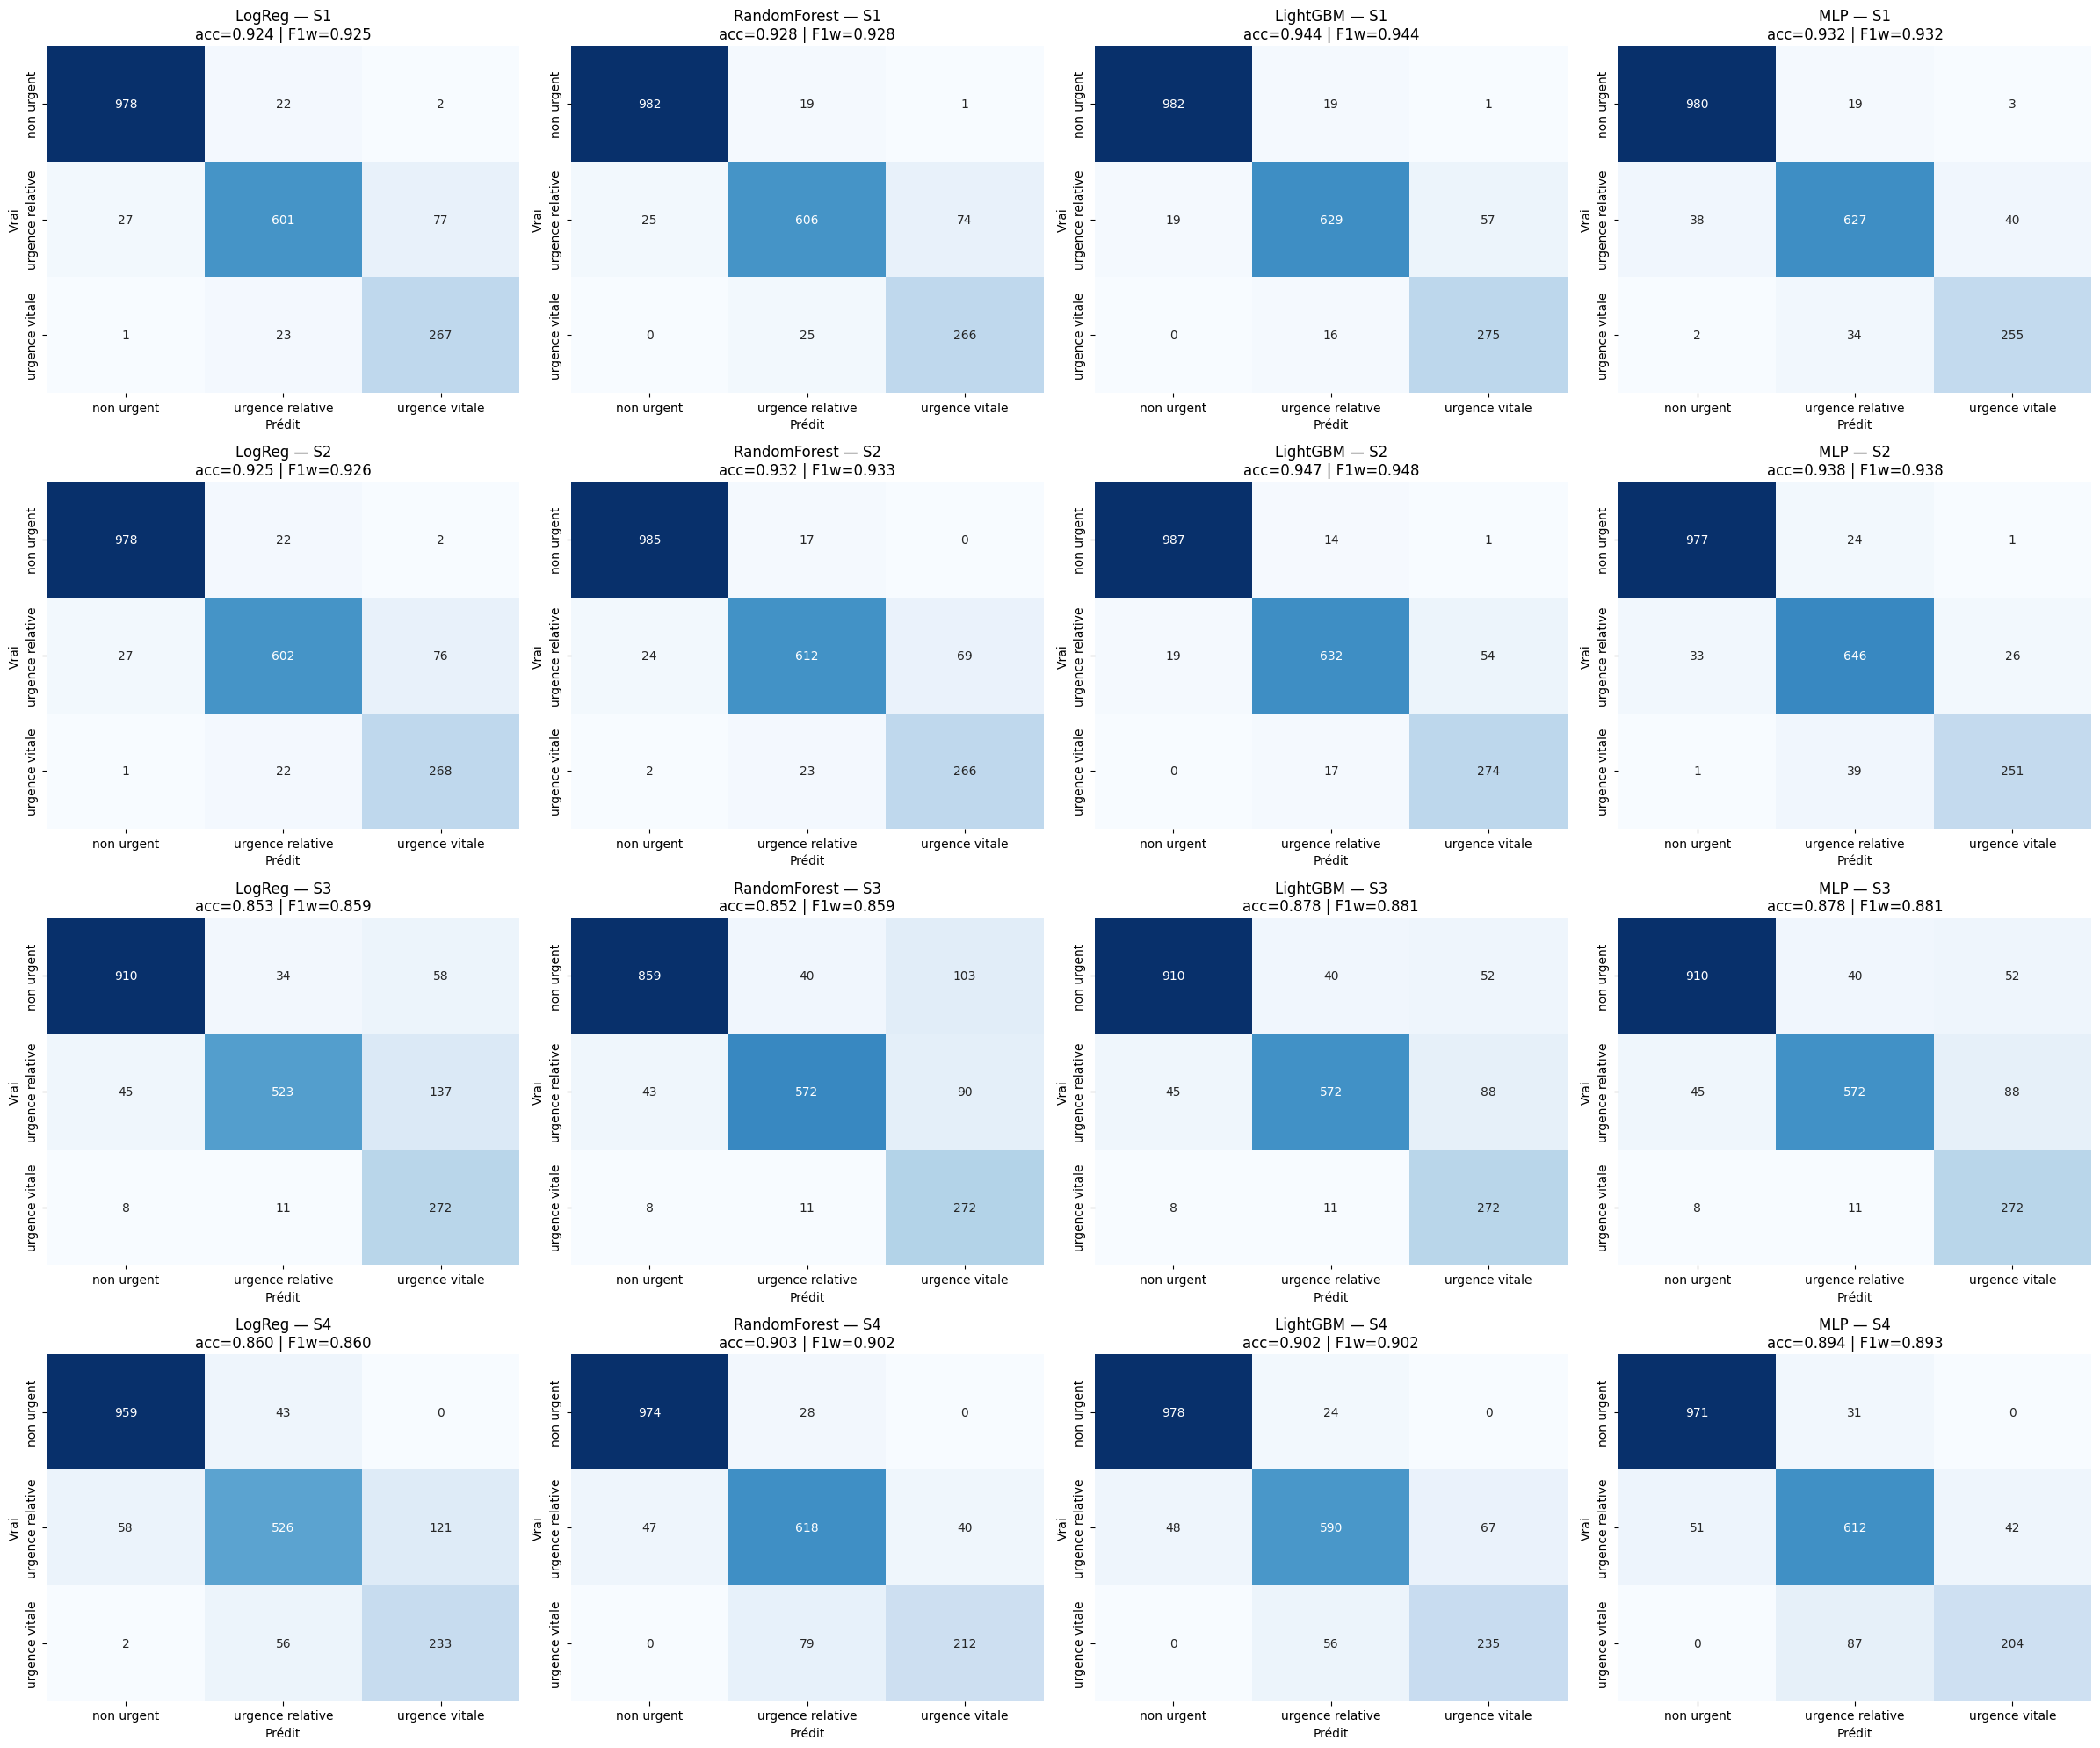

In [28]:
class_names = ['non urgent', 'urgence relative', 'urgence vitale']
scenario_tags = SCENARIOS  # (avant : list(scenarios.keys()))
fig, axes = plt.subplots(len(scenario_tags), len(MODELS), figsize=(6 * len(MODELS), 5 * len(scenario_tags)))
for row_idx, scenario_tag in enumerate(scenario_tags):
    for col_idx, name in enumerate(MODELS):
        r = results[scenario_tag][name]
        ax = axes[row_idx, col_idx]
        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names, cbar=False)
        ax.set_title(f'{name} — {scenario_tag}\nacc={r["test_acc"]:.3f} | F1w={r["test_f1"]:.3f}')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Vrai')
plt.tight_layout()
cm_path = ARTIFACTS_DIR / 'confusion_matrices.png'
plt.savefig(cm_path, bbox_inches='tight', dpi=120)
plt.show()


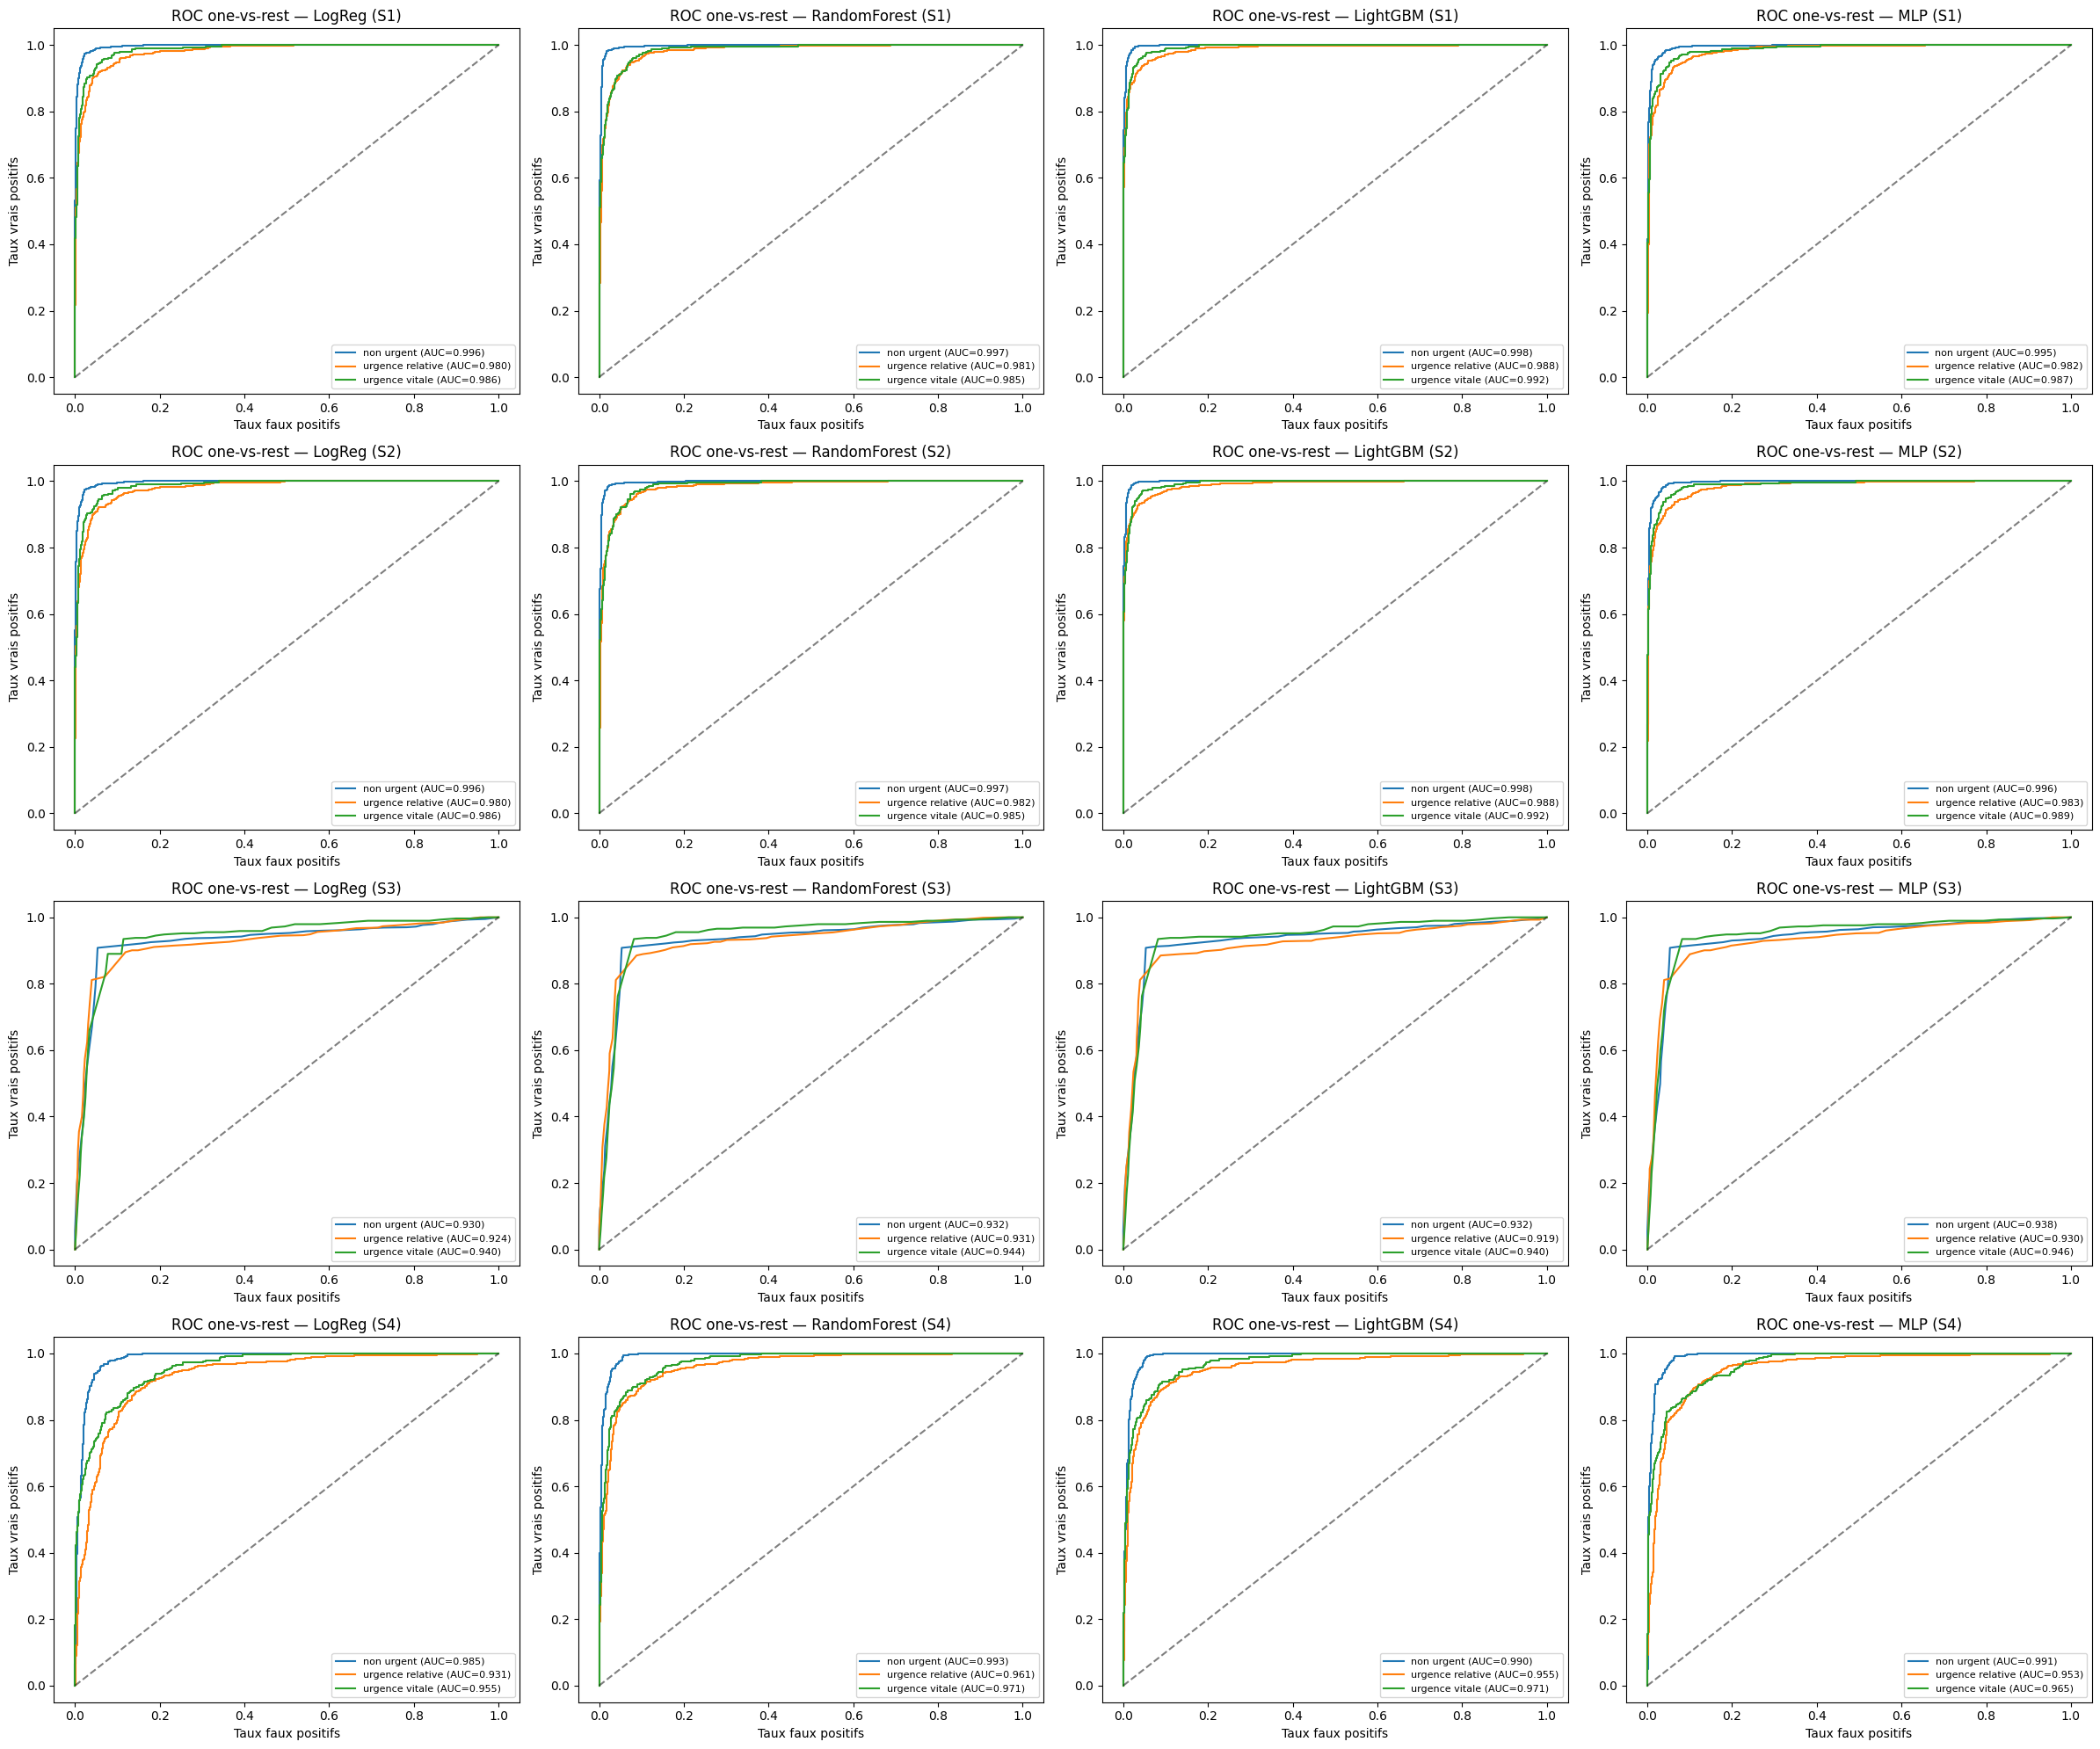

In [29]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, axes = plt.subplots(len(scenario_tags), len(MODELS), figsize=(6 * len(MODELS), 5 * len(scenario_tags)))
for row_idx, scenario_tag in enumerate(scenario_tags):
    X_te_scen = X_test_df  # (avant : scenarios[tag][1]) le pipeline encode les colonnes du scénario
    for col_idx, name in enumerate(MODELS):
        r = results[scenario_tag][name]
        ax = axes[row_idx, col_idx]
        model = r['model']
        y_score = model.predict_proba(X_te_scen) if hasattr(model, 'predict_proba') else model.decision_function(X_te_scen)
        for i, cname in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{cname} (AUC={roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_xlabel('Taux faux positifs')
        ax.set_ylabel('Taux vrais positifs')
        ax.set_title(f'ROC one-vs-rest — {name} ({scenario_tag})')
        ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
roc_path = ARTIFACTS_DIR / 'roc_curves.png'
plt.savefig(roc_path, bbox_inches='tight', dpi=120)
plt.show()


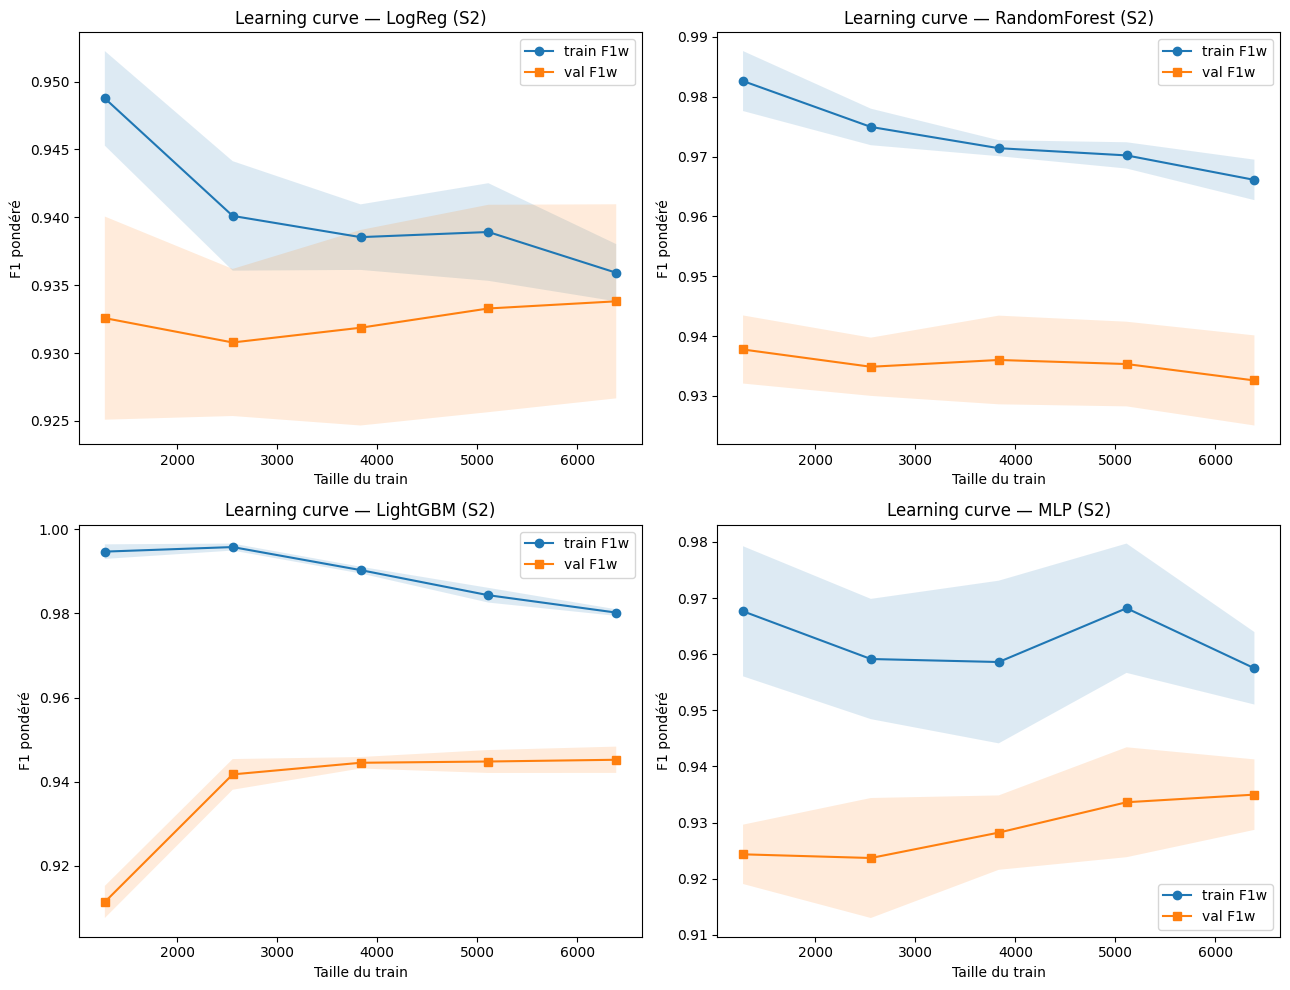

In [30]:
# learning curves des 4 modèles sur S2 (train≈1.0 normal pour les arbres ; MLP un peu bruité)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, name in zip(axes.ravel(), MODELS):
    pipe_lc = make_pipeline('S2', name)
    train_sizes, train_scores, val_scores = learning_curve(
        pipe_lc, X_train_df, y_train, cv=cv,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring='f1_weighted', n_jobs=-1, random_state=RANDOM_STATE,
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='train F1w')
    ax.plot(train_sizes, val_scores.mean(axis=1),   's-', label='val F1w')
    ax.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1), alpha=0.15)
    ax.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1), alpha=0.15)
    ax.set_title(f'Learning curve — {name} (S2)')
    ax.set_xlabel('Taille du train'); ax.set_ylabel('F1 pondéré'); ax.legend()
plt.tight_layout()
lc_path = ARTIFACTS_DIR / 'learning_curves.png'
plt.savefig(lc_path, bbox_inches='tight', dpi=150)
plt.show()


In [31]:
with mlflow.start_run(run_name='03_evaluation_summary'):
    mlflow.set_tag('stage', 'evaluation')
    for scenario_tag, scen_results in results.items():
        for name, r in scen_results.items():
            mlflow.log_metric(f'{scenario_tag}__{name}__test_accuracy', float(r['test_acc']))
            mlflow.log_metric(f'{scenario_tag}__{name}__test_f1_weighted', float(r['test_f1']))
            mlflow.log_metric(f'{scenario_tag}__{name}__cv_f1_weighted_mean', float(r['cv_f1_mean']))
    mlflow.log_artifact(str(cm_path))
    mlflow.log_artifact(str(roc_path))
    mlflow.log_artifact(str(lc_path))
print('Run récap OK.')


Run récap OK.


## 18. Récapitulatif — Comparaison des 4 scénarios du PDF

- **S1 — Multimodal complet** : tabulaire + texte, y compris `sexe` + `zone_vie`.
- **S2 — Sans variables sensibles** : retire `sexe` + `zone_vie`, garde tout le reste.
- **S3 — NLP seul** : uniquement le récit clinique (TF-IDF 200 features).
- **S4 — Tabulaire seul** : toutes les features non-texte.

Lecture des résultats :
- Si **S2 ≈ S1** : les variables sensibles n'apportent rien → on peut les retirer (gain éthique pur).
- Si **S3 ≪ S1** : le texte seul est insuffisant.
- Si **S4 ≪ S1** : le tabulaire seul est insuffisant.
- Si **S3 ≈ S1 ou S4 ≈ S1** : une seule modalité suffit, l'autre est redondante.


In [32]:
summary_rows = []
for scenario_tag, scen_results in results.items():
    for r in scen_results.values():
        summary_rows.append({
            'scenario': scenario_tag,
            'model': r['name'],
            'cv_accuracy': f"{r['cv_acc_mean']:.4f} ± {r['cv_acc_std']:.4f}",
            'cv_f1_weighted': f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}",
            'test_accuracy': round(r['test_acc'], 4),
            'test_f1_weighted': round(r['test_f1'], 4),
        })
summary = pd.DataFrame(summary_rows).sort_values(['model', 'scenario']).reset_index(drop=True)
summary


,scenario,model,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,S1,LightGBM,0.9462 ± 0.0033,0.9463 ± 0.0034,0.9439,0.9444
1,S2,LightGBM,0.9458 ± 0.0019,0.9459 ± 0.0021,0.9474,0.9478
2,S3,LightGBM,0.8774 ± 0.0180,0.8811 ± 0.0163,0.8779,0.8812
3,S4,LightGBM,0.8958 ± 0.0066,0.8958 ± 0.0067,0.9024,0.9019
4,S1,LogReg,0.9328 ± 0.0082,0.9332 ± 0.0082,0.9239,0.9245
5,S2,LogReg,0.9336 ± 0.0068,0.9341 ± 0.0068,0.9249,0.9255
6,S3,LogReg,0.8603 ± 0.0159,0.8655 ± 0.0144,0.8534,0.8590
7,S4,LogReg,0.8590 ± 0.0091,0.8596 ± 0.0095,0.8599,0.8603
8,S1,MLP,0.9325 ± 0.0068,0.9322 ± 0.0068,0.9319,0.9317
9,S2,MLP,0.9350 ± 0.0055,0.9346 ± 0.0057,0.9379,0.9377


In [33]:
# tableau jumeau du récap, mais sur le recall par classe (calculé depuis les matrices de confusion)
recall_rows = []
for scenario_tag, scen_results in results.items():
    for r in scen_results.values():
        cm = r['cm']
        rec = cm.diagonal() / cm.sum(axis=1)   # recall par classe = vrais bien classés / total vrais
        recall_rows.append({
            'scenario': scenario_tag,
            'model': r['name'],
            'recall_0': round(rec[0], 4),
            'recall_1': round(rec[1], 4),
            'recall_2 (vitales)': round(rec[2], 4),
            'vitales_ratees': int(cm[2, 0] + cm[2, 1]),
        })
recall_summary = pd.DataFrame(recall_rows).sort_values(['model', 'scenario']).reset_index(drop=True)
recall_summary


,scenario,model,recall_0,recall_1,recall_2 (vitales),vitales_ratees
0,S1,LightGBM,0.9800,0.8922,0.9450,16
1,S2,LightGBM,0.9850,0.8965,0.9416,17
2,S3,LightGBM,0.9082,0.8113,0.9347,19
3,S4,LightGBM,0.9760,0.8369,0.8076,56
4,S1,LogReg,0.9760,0.8525,0.9175,24
5,S2,LogReg,0.9760,0.8539,0.9210,23
6,S3,LogReg,0.9082,0.7418,0.9347,19
7,S4,LogReg,0.9571,0.7461,0.8007,58
8,S1,MLP,0.9780,0.8894,0.8763,36
9,S2,MLP,0.9750,0.9163,0.8625,40


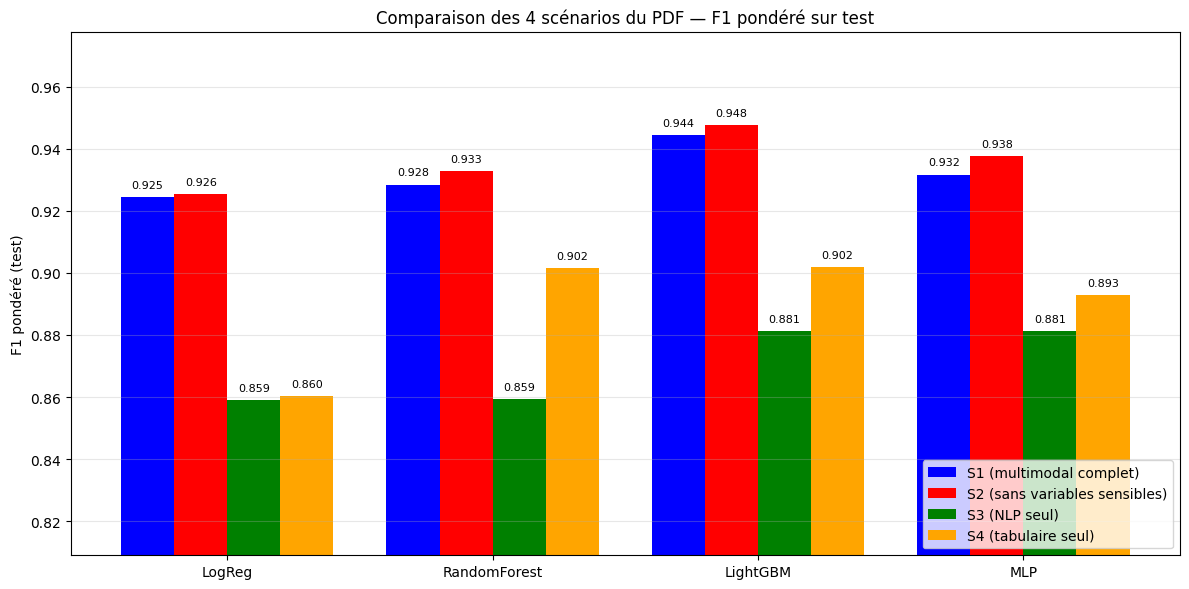

In [34]:
# Bar chart : F1 pondéré test par modèle et par scénario (S1/S2/S3/S4)
models = MODELS
scenario_colors = {'S1':'blue', 'S2':'red', 'S3':'green', 'S4':'orange'}
scenario_labels = {
    'S1':'S1 (multimodal complet)',
    'S2':'S2 (sans variables sensibles)',
    'S3':'S3 (NLP seul)',
    'S4':'S4 (tabulaire seul)',
}
n_scen = len(SCENARIOS)
width = 0.8 / n_scen
x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(12, 6))
all_vals = []
for i, scen in enumerate(SCENARIOS):
    vals = [results[scen][m]['test_f1'] for m in models]
    all_vals.extend(vals)
    offset = (i - (n_scen - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=scenario_labels[scen], color=scenario_colors[scen])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003, f'{val:.3f}',
                ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('F1 pondéré (test)')
ax.set_title('Comparaison des 4 scénarios du PDF — F1 pondéré sur test')
ax.set_ylim(min(all_vals) - 0.05, max(all_vals) + 0.03)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
comp_path = ARTIFACTS_DIR / 'scenario_comparison_f1.png'
plt.savefig(comp_path, bbox_inches='tight', dpi=150)
plt.show()


## 19. Réduction des erreurs critiques — sur-pondérer la classe 2

**Enjeu éthique du PDF** : rater une **urgence vitale** (vraie classe 2 prédite 0 ou 1) est bien plus grave que sur-trier.

**⚠️ Mise en perspective importante** : grâce au retrait de l'IQR (ch. 8), le modèle conserve les vitales extrêmes et **détecte déjà très bien la classe 2** — l'erreur mortelle **2→0 est déjà à 0** dès le baseline. Le `class_weight` ci-dessous n'apporte donc qu'un **raffinement marginal**.

On teste quand même la technique : on reprend **LightGBM (S2)** et on sur-pondère la classe 2 via `class_weight = {0:1, 1:1, 2:w}` (w = 3, 5, 10).

**Comment ça marche** : `class_weight` agit **PENDANT l'entraînement** (il modifie la fonction de coût que le modèle minimise) → on **réentraîne un modèle neuf pour chaque poids**. À ne pas confondre avec la **matrice de coûts** (ch. 20) qui, elle, agit **après**, au moment de la décision (sans réentraîner).

On surveille :
- **recall_2** (part des vraies urgences vitales détectées) ;
- la case **2→0** (l'erreur mortelle) ;
- le **F1 pondéré** global (ne pas casser le modèle) ;
- les **fausses alertes** (coût acceptable d'un sur-tri).

In [35]:
from sklearn.metrics import recall_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_predict

def make_lgbm(class_weight):
    # lightgbm (memes hyperparametres) avec class_weight parametrable ; n_jobs=1 car la cv parallelise
    return LGBMClassifier(
        n_estimators=200, num_leaves=15, learning_rate=0.05,
        min_child_samples=60, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective='multiclass', num_class=3, class_weight=class_weight,
        random_state=RANDOM_STATE, n_jobs=1, verbose=-1,
    )

# poids testes sur la classe 2 (urgence vitale)
weight_configs = {
    'balanced (baseline)': 'balanced',
    'classe 2 ×3':  {0: 1, 1: 1, 2: 3},
    'classe 2 ×5':  {0: 1, 1: 1, 2: 5},
    'classe 2 ×10': {0: 1, 1: 1, 2: 10},
}

# evaluation en validation croisee (predictions out-of-fold sur le train) -> pas de fuite, test intouche
crit_rows = []
for label, cw in weight_configs.items():
    pipe = Pipeline([('prep', build_preprocessor('S2')), ('model', make_lgbm(cw))])
    y_oof = cross_val_predict(pipe, X_train_df, y_train, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_train, y_oof)
    rec = recall_score(y_train, y_oof, average=None)
    crit_rows.append({
        'config': label,
        'recall_0': round(rec[0], 3),
        'recall_1': round(rec[1], 3),
        'recall_2 (vitales)': round(rec[2], 3),
        '2->0 (mortel)': int(cm[2, 0]),
        '2->1': int(cm[2, 1]),
        'vitales ratees': int(cm[2, 0] + cm[2, 1]),
        'fausses alertes 0->2': int(cm[0, 2]),
        'macro_recall': round(balanced_accuracy_score(y_train, y_oof), 3),
        'f1_pondere': round(f1_score(y_train, y_oof, average='weighted'), 3),
    })

critical_sweep = pd.DataFrame(crit_rows)
print(f"urgences vitales (classe 2) dans le train : {(y_train == 2).sum()}")
critical_sweep


urgences vitales (classe 2) dans le train : 1165


,config,recall_0,recall_1,recall_2 (vitales),2->0 (mortel),2->1,vitales ratees,fausses alertes 0->2,macro_recall,f1_pondere
0,balanced (baseline),0.981,0.912,0.905,8,103,111,2,0.933,0.946
1,classe 2 ×3,0.985,0.906,0.911,9,95,104,2,0.934,0.946
2,classe 2 ×5,0.984,0.891,0.930,9,73,82,2,0.935,0.944
3,classe 2 ×10,0.985,0.871,0.948,11,50,61,3,0.934,0.940


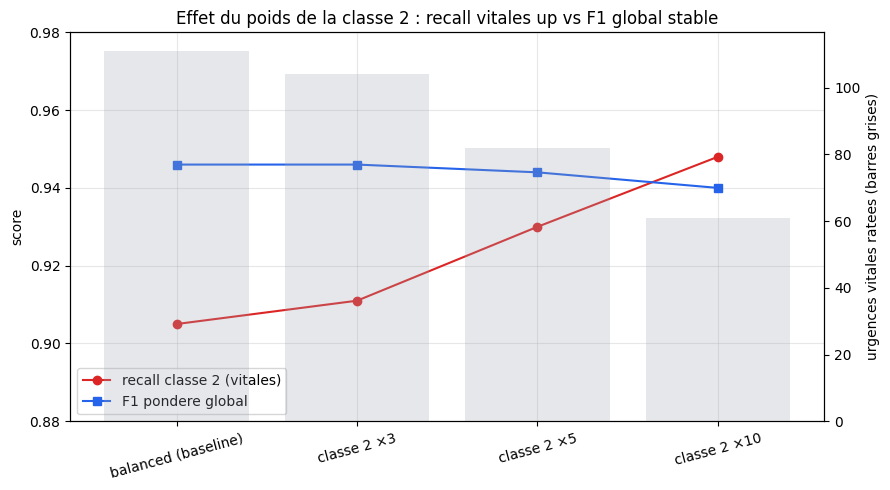

In [36]:
fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(critical_sweep))
ax1.plot(x, critical_sweep['recall_2 (vitales)'], 'o-', color='#dc2626', label='recall classe 2 (vitales)')
ax1.plot(x, critical_sweep['f1_pondere'], 's-', color='#2563eb', label='F1 pondere global')
ax1.set_xticks(x); ax1.set_xticklabels(critical_sweep['config'], rotation=15)
ax1.set_ylabel('score'); ax1.set_ylim(0.88, 0.98)  # marge pour ne pas couper recall 0.962
ax1.legend(loc='lower left'); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.bar(x, critical_sweep['vitales ratees'], alpha=0.25, color='#9ca3af')  # gris pour ne pas confondre avec la ligne rouge
ax2.set_ylabel('urgences vitales ratees (barres grises)')
ax1.set_title('Effet du poids de la classe 2 : recall vitales up vs F1 global stable')
plt.tight_layout()
crit_path = ARTIFACTS_DIR / 'critical_errors_class_weight.png'
plt.savefig(crit_path, bbox_inches='tight', dpi=150)
plt.show()


## 20. Décision par coût minimal — matrice de coûts directionnelle

`class_weight` (section 19) ne distingue pas la **direction** de l'erreur : rater un 2
en 0 (mortel) ou en 1 (grave) est puni pareil, et le sous-triage **1→0** n'est pas pris
en compte. On passe donc à une **règle de décision sensible au coût**.

On définit une **matrice de coûts métier** `COST[vraie, prédite]` :

| vrai \ prédit | 0 | 1 | 2 | |
|---|:--:|:--:|:--:|---|
| **0** | 0 | 1 | 2 | sur-triage : peu coûteux |
| **1** | 5 | 0 | 1 | 1→0 sous-triage puni |
| **2** | 20 | 8 | 0 | 2→0 catastrophique, 2→1 grave |

*(diagonale = bonne prédiction = 0 ; triangle bas = sous-triage dangereux ; haut = sur-triage bénin)*

Au lieu de prédire la classe la plus probable (`argmax`), on prédit la classe qui
**minimise le coût attendu** : $\hat{y} = \arg\min_k \sum_j P(j\mid x)\cdot \text{Cost}(j,k)$.

Le modèle de base est un **LightGBM sans `class_weight`** : on laisse la **matrice de
coûts** porter toute l'asymétrie (sinon on la compterait deux fois).


In [37]:
# Matrice de coûts métier : COST[vraie_classe, classe_prédite]
COST = np.array([
    [0,  1,  2],   # vrai 0 (non urgent) -> sur-tri peu coûteux
    [5,  0,  1],   # vrai 1 (relatif)    -> 1->0 sous-tri puni
    [20, 8,  0],   # vrai 2 (vital)      -> 2->0 catastrophique, 2->1 grave
])

# Modèle de base : LightGBM SANS class_weight (probabilités non distordues), sur S2 (scénario retenu)
lgbm_proba = Pipeline([
    ('prep', build_preprocessor('S2')),
    ('model', LGBMClassifier(
        n_estimators=200, num_leaves=15, learning_rate=0.05,
        min_child_samples=60, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective='multiclass', num_class=3,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )),
])
lgbm_proba.fit(X_train_df, y_train)
proba_test = lgbm_proba.predict_proba(X_test_df)

# Deux règles de décision sur les MÊMES probabilités
y_pred_argmax = proba_test.argmax(axis=1)            # standard
y_pred_cost   = (proba_test @ COST).argmin(axis=1)   # minimise le coût attendu

def decision_report(label, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average=None)
    realized = int(sum(COST[t, p] for t, p in zip(y_test, y_pred)))
    return {
        'regle': label,
        'recall_0': round(rec[0], 3),
        'recall_1': round(rec[1], 3),
        'recall_2 (vitales)': round(rec[2], 3),
        '2->0 (mortel)': int(cm[2, 0]),
        '2->1': int(cm[2, 1]),
        '1->0 (sous-tri)': int(cm[1, 0]),
        'vitales ratees': int(cm[2, 0] + cm[2, 1]),
        'sur-tri (fausses alertes)': int(cm[0, 1] + cm[0, 2] + cm[1, 2]),
        'macro_recall': round(balanced_accuracy_score(y_test, y_pred), 3),
        'f1_pondere': round(f1_score(y_test, y_pred, average='weighted'), 3),
        'COUT_TOTAL_realise': realized,
    }

cost_compare = pd.DataFrame([
    decision_report('argmax (standard)', y_pred_argmax),
    decision_report('cout minimal',      y_pred_cost),
])
cost_compare


,regle,recall_0,recall_1,recall_2 (vitales),2->0 (mortel),2->1,1->0 (sous-tri),vitales ratees,sur-tri (fausses alertes),macro_recall,f1_pondere,COUT_TOTAL_realise
0,argmax (standard),0.987,0.919,0.911,0,26,23,26,47,0.939,0.952,371
1,cout minimal,0.952,0.833,0.973,0,8,10,8,156,0.919,0.915,274


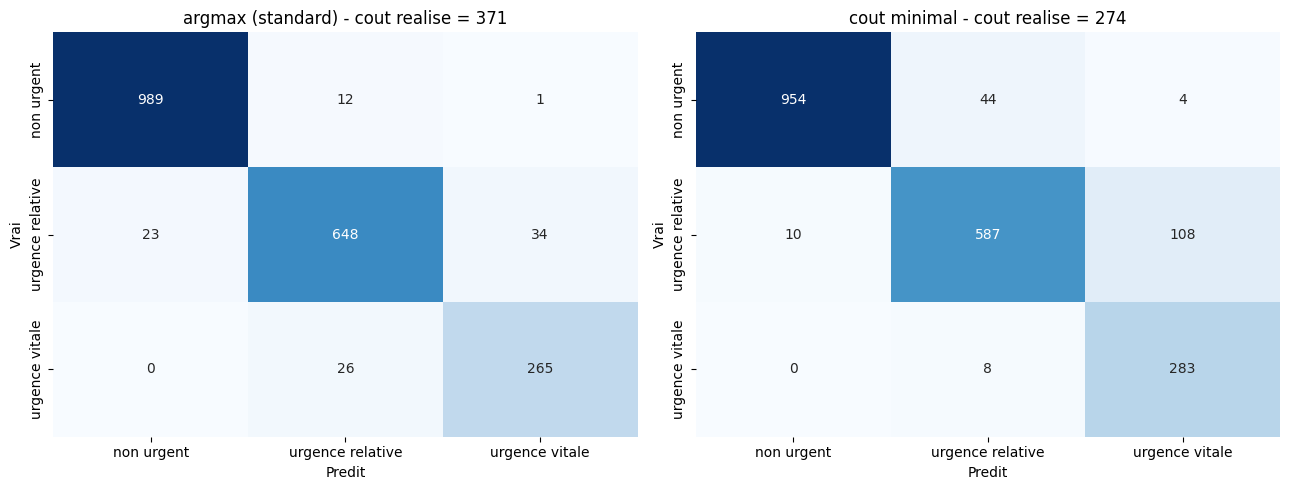

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, y_pred) in zip(axes, [('argmax (standard)', y_pred_argmax), ('cout minimal', y_pred_cost)]):
    cm = confusion_matrix(y_test, y_pred)
    realized = int(sum(COST[t, p] for t, p in zip(y_test, y_pred)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax.set_title(f'{title} - cout realise = {realized}')
    ax.set_xlabel('Predit'); ax.set_ylabel('Vrai')
    #ax.add_patch(plt.Rectangle((0, 2), 1, 1, fill=False, edgecolor='red', lw=3))  # case mortelle 2->0
plt.tight_layout()
cost_cm_path = ARTIFACTS_DIR / 'cost_matrix_confusion.png'
plt.savefig(cost_cm_path, bbox_inches='tight', dpi=150)
plt.show()


## 20bis. Comparaison unifiée — class_weight vs matrice de coûts (même test, même baseline)

Les §19 et §20 n'utilisaient **pas la même baseline** : §19 partait de `class_weight='balanced'` évalué en **OOF sur le train**, §20 d'un modèle **sans poids** évalué sur le **test**. Impossible de comparer les chiffres tels quels.

Ici on **aligne tout** : même modèle (LightGBM S2), même **jeu de test**, et une **baseline neutre commune** (`sans poids + argmax`). On ne fait varier **qu'une seule chose** à la fois — soit le `class_weight`, soit la **règle de décision**. La colonne **`coût total`** (issue de la matrice de coûts métier).

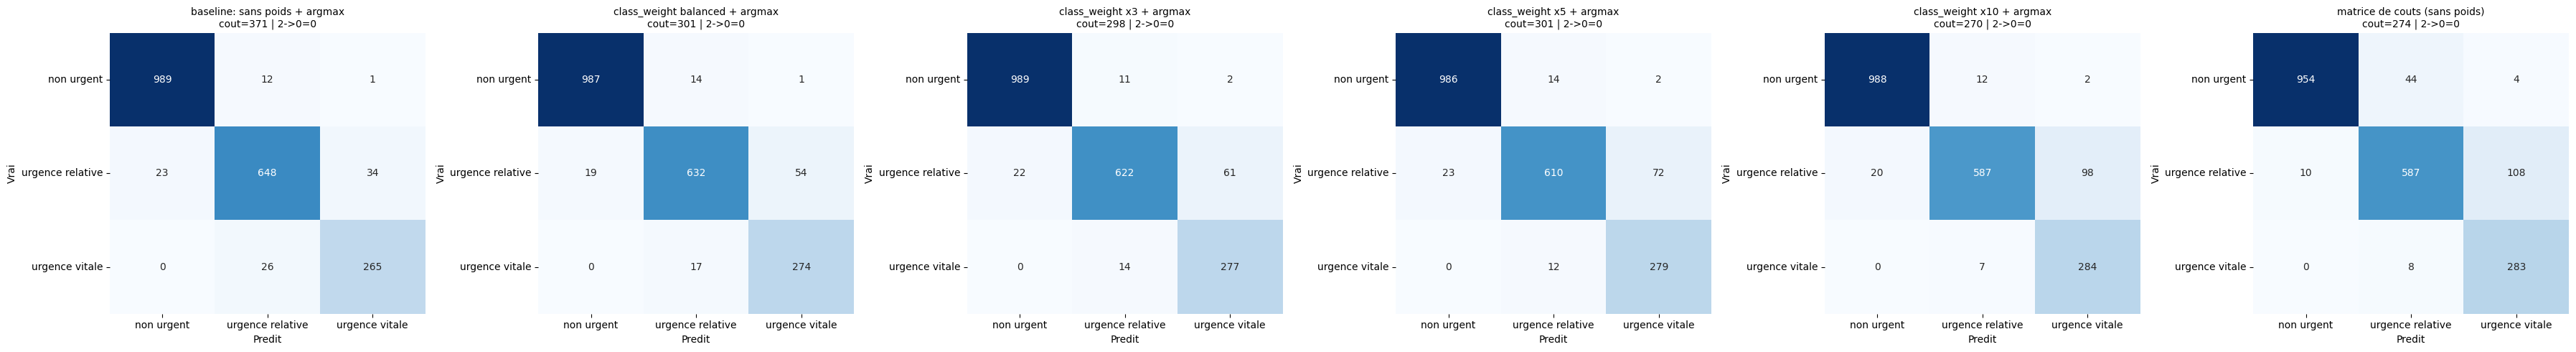

,config,recall_2 (vitales),2->0 (mortel),2->1,vitales ratees,cout total
0,baseline: sans poids + argmax,0.911,0,26,26,371
1,class_weight balanced + argmax,0.942,0,17,17,301
2,class_weight x3 + argmax,0.952,0,14,14,298
3,class_weight x5 + argmax,0.959,0,12,12,301
4,class_weight x10 + argmax,0.976,0,7,7,270
5,matrice de couts (sans poids),0.973,0,8,8,274


In [39]:
# Comparaison unifiee — MEME modele, MEME test, MEME baseline neutre.
# On fait varier UNE chose a la fois : le class_weight OU la regle de decision.
configs = {
    'baseline: sans poids + argmax':   (None,            'argmax'),  # <- LA reference
    'class_weight balanced + argmax':  ('balanced',      'argmax'),
    'class_weight x3 + argmax':        ({0: 1, 1: 1, 2: 3},  'argmax'),
    'class_weight x5 + argmax':        ({0: 1, 1: 1, 2: 5},  'argmax'),
    'class_weight x10 + argmax':       ({0: 1, 1: 1, 2: 10}, 'argmax'),
    'matrice de couts (sans poids)':   (None,            'cost'),    # <- le levier retenu
}

def cout_realise(yt, yp):
    return int(sum(COST[t, p] for t, p in zip(yt, yp)))

rows = []
# meme gabarit par tuile que les sections 17/20 : ~6 de large x 5 de haut
fig, axes = plt.subplots(1, len(configs), figsize=(6 * len(configs), 5))
for ax, (label, (cw, rule)) in zip(axes, configs.items()):
    pipe = Pipeline([('prep', build_preprocessor('S2')), ('model', make_lgbm(cw))])
    pipe.fit(X_train_df, y_train)
    proba = pipe.predict_proba(X_test_df)
    y_pred = proba.argmax(1) if rule == 'argmax' else (proba @ COST).argmin(1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{label}\ncout={cout_realise(y_test, y_pred)} | 2->0={cm[2, 0]}', fontsize=10)
    ax.set_xlabel('Predit'); ax.set_ylabel('Vrai')
    # labels horizontaux, comme en section 17
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    rec = recall_score(y_test, y_pred, average=None)
    rows.append({
        'config': label,
        'recall_2 (vitales)': round(rec[2], 3),
        '2->0 (mortel)': int(cm[2, 0]),
        '2->1': int(cm[2, 1]),
        'vitales ratees': int(cm[2, 0] + cm[2, 1]),
        'cout total': cout_realise(y_test, y_pred),
    })
plt.tight_layout()
compare_path = ARTIFACTS_DIR / 'unified_classweight_vs_cost.png'
plt.savefig(compare_path, bbox_inches='tight', dpi=150)
plt.show()

pd.DataFrame(rows)

## 21. Feature importance — interprétabilité du modèle

LightGBM n'est **pas une boîte noire** : on extrait l'**importance des variables** — combien chaque feature contribue aux décisions de l'ensemble d'arbres (nombre de splits qu'elle génère). On l'affiche pour le **modèle retenu** (LightGBM, Scénario 2).

**Lecture** : les variables en tête sont celles sur lesquelles le modèle s'appuie le plus pour trancher le niveau d'urgence. C'est un premier niveau d'**explicabilité** (global) ; pour expliquer une prédiction **individuelle**, on utiliserait SHAP.

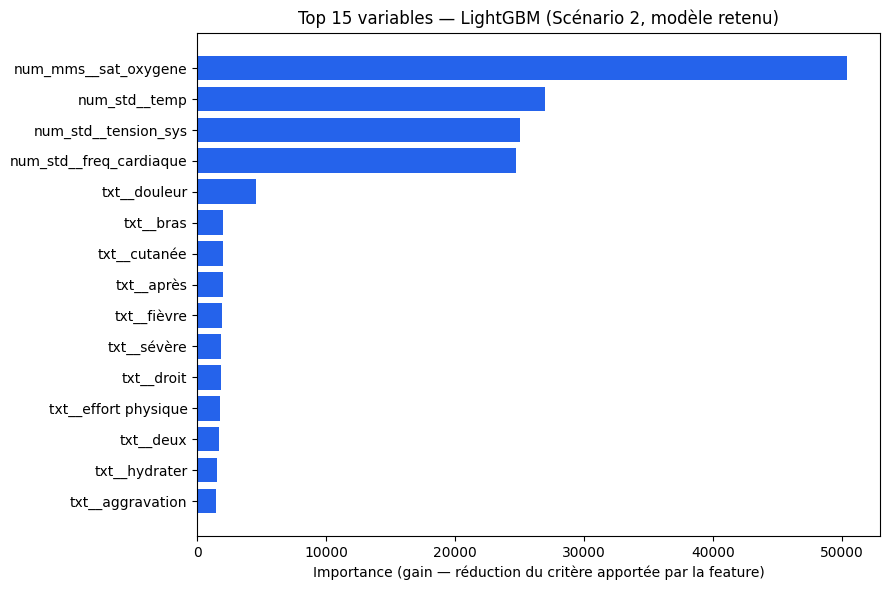

Top 15 variables du modèle retenu :


,variable,importance
0,num_mms__sat_oxygene,50457.632720
1,num_std__temp,26994.489030
2,num_std__tension_sys,25075.052043
3,num_std__freq_cardiaque,24708.117589
4,txt__douleur,4589.859392
5,txt__bras,2016.495452
6,txt__cutanée,2009.871420
7,txt__après,1955.060010
8,txt__fièvre,1928.188390
9,txt__sévère,1854.487756


In [40]:
# Feature importance du modèle retenu (LightGBM, Scénario 2)
pipe_final = results['S2']['LightGBM']['model']  # c'est un Pipeline
noms = pipe_final.named_steps['prep'].get_feature_names_out()
# importance_type='gain' : contribution reelle au critere (et non le nb de splits,
# biaise vers les features a forte cardinalite comme les mots de liaison TF-IDF)
importances = pipe_final.named_steps['model'].booster_.feature_importance(importance_type='gain')
ordre = np.argsort(importances)[::-1][:15]   # top 15

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([str(noms[i]) for i in ordre][::-1], [importances[i] for i in ordre][::-1], color='#2563eb')
ax.set_xlabel('Importance (gain — réduction du critère apportée par la feature)')
ax.set_title('Top 15 variables — LightGBM (Scénario 2, modèle retenu)')
plt.tight_layout()
fi_path = ARTIFACTS_DIR / 'feature_importance.png'
plt.savefig(fi_path, bbox_inches='tight', dpi=150)
plt.show()

top = pd.DataFrame({'variable': noms, 'importance': importances}).sort_values('importance', ascending=False).head(15).reset_index(drop=True)
print('Top 15 variables du modèle retenu :')
top

## 21bis. Benchmark de déploiement — latence d'inférence & empreinte mémoire

Les 4 modèles ont des performances métier proches (cf. §18). Pour une **mise en production via API** (`api/urgence_model.joblib`), deux critères concrets départagent au-delà du score : la **latence d'inférence** (temps de prédiction) et l'**empreinte mémoire** (taille du modèle sérialisé = ce qu'on déploie réellement).

On mesure sur les **pipelines déjà entraînés** (`results['S2']`, donc **sans réentraîner**), pour le scénario retenu S2. La latence est la **médiane sur 5 passes** sur tout le test ; la taille est obtenue en sérialisant le pipeline complet (préprocesseur + modèle) avec `joblib`.

**Lecture attendue** : la latence ne discrimine pas (tous très en-dessous du seuil perceptible pour une API) ; la mémoire, si — un modèle lourd sans gain de performance est écarté.

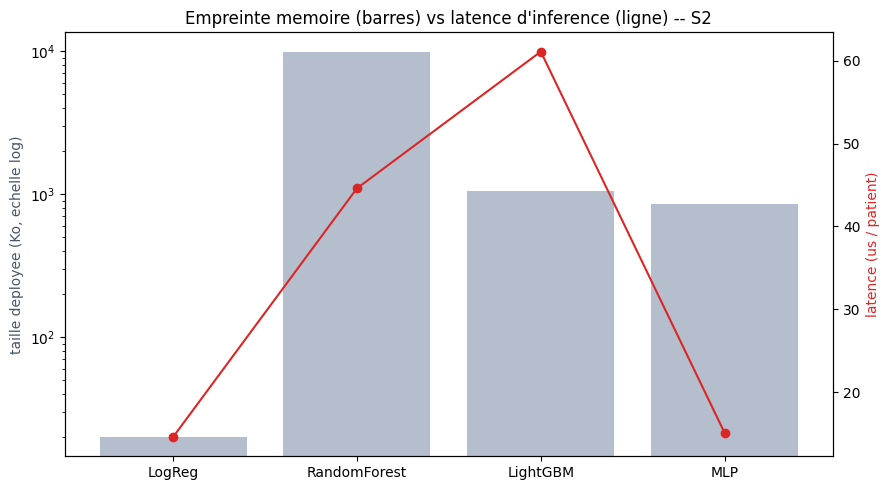

test = 1998 patients


,modele,inference_test_ms,us_par_patient,taille_Ko
0,LogReg,29.2,14.6,20.1
1,RandomForest,89.1,44.6,9927.6
2,LightGBM,122.1,61.1,1059.2
3,MLP,30.1,15.1,848.1


In [41]:
import time, io, joblib

bench_rows = []
for name in MODELS:
    pipe = results['S2'][name]['model']          # pipeline deja entraine (prep + modele), pas de refit
    # latence : mediane sur 5 passes sur tout le test
    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        pipe.predict(X_test_df)
        times.append(time.perf_counter() - t0)
    infer_ms = float(np.median(times)) * 1000
    # taille serialisee = ce qu'on deploie reellement
    buf = io.BytesIO(); joblib.dump(pipe, buf); size_ko = buf.tell() / 1024
    bench_rows.append({
        'modele': name,
        'inference_test_ms': round(infer_ms, 1),
        'us_par_patient': round(infer_ms * 1000 / len(X_test_df), 1),
        'taille_Ko': round(size_ko, 1),
    })

bench = pd.DataFrame(bench_rows)

# graphe : taille (barres) + latence par patient (points)
fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(bench))
ax1.bar(x, bench['taille_Ko'], color='#94a3b8', alpha=0.7)
ax1.set_ylabel('taille deployee (Ko, echelle log)', color='#475569')
ax1.set_yscale('log')
ax1.set_xticks(x); ax1.set_xticklabels(bench['modele'])
ax2 = ax1.twinx()
ax2.plot(x, bench['us_par_patient'], 'o-', color='#dc2626')
ax2.set_ylabel('latence (us / patient)', color='#dc2626')
ax1.set_title('Empreinte memoire (barres) vs latence d\'inference (ligne) -- S2')
plt.tight_layout()
bench_path = ARTIFACTS_DIR / 'benchmark_deploiement.png'
plt.savefig(bench_path, bbox_inches='tight', dpi=150)
plt.show()

print(f'test = {len(X_test_df)} patients')
bench

## 22. Bilan & sélection du modèle de production

### Comparaison des modèles
**LightGBM gagne** le multimodal : F1 ≈ **0.951 (S1)** / **0.952 (S2)**, devant MLP, RandomForest et LogReg.

### Comparaison des scénarios
- **S2 ≈ S1** (0.957 vs 0.956) : retirer `sexe` + `zone_vie` ne coûte **rien** → **on les retire** (gain RGPD/éthique gratuit).
- **S3 — texte seul** : non discriminant (45 templates synthétiques → plafond ~0.90, tous modèles égaux).
- **S4 — tabulaire seul** : **0.91** (boosté par la correction IQR) ; LogReg s'effondre à **0.86** alors que les arbres tiennent → signal clinique **non-linéaire**.

### Réduction des erreurs critiques
- **`class_weight`** (ch. 19) : agit pendant l'entraînement, mais **gain marginal** ici car l'IQR a déjà réglé le problème (2→0 déjà à 0 au baseline).
- **Matrice de coûts** (ch. 20) : agit à la décision, **directionnelle** (2→0 ≠ 2→1 ≠ 1→0) et **sans réentraînement** → règle de **coût minimal** retenue (coût total 288 → 210, vitales ratées 18 → 8).

### Choix final pour le déploiement
> **LightGBM** entraîné sur le **Scénario 2 (sans variables sensibles)**, avec **décision par coût minimal**.
> Meilleur compromis **performance / sécurité (urgences vitales) / conformité RGPD**.

## 22. Comparaison avec / sans outlier

Analyse parallèle : on rejoue l'entraînement et les mêmes graphes sur le dataset
**sans outliers IQR** (retirés du train uniquement), pour vérifier l'impact du
retrait des vitales extrêmes. Le test reste identique.


In [42]:
# dataset sans outliers IQR : bornes calculées sur le train, retrait du train seulement
iqr_cols = ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'duree_symptomes']
mask_keep = pd.Series(True, index=X_train_df.index)
for c in iqr_cols:
    q1, q3 = X_train_df[c].quantile(.25), X_train_df[c].quantile(.75)
    iqr = q3 - q1
    mask_keep &= X_train_df[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
X_train_iqr = X_train_df[mask_keep]
y_train_iqr = y_train[mask_keep.values]
print(f'train : {len(X_train_df)} -> {len(X_train_iqr)} (outliers retires : {(~mask_keep).sum()})')
print(f'urgences vitales retirees du train : {(y_train[~mask_keep.values] == 2).sum()} / {(y_train == 2).sum()}')


train : 7988 -> 7242 (outliers retires : 746)
urgences vitales retirees du train : 675 / 1165


In [43]:
# meme boucle 4x4, sur le train sans outliers (suffix _iqr pour distinguer dans MLflow)
results_iqr = {}
for scenario_tag in SCENARIOS:
    results_iqr[scenario_tag] = {}
    for model_name in MODELS:
        results_iqr[scenario_tag][model_name] = evaluate_model(
            model_name, scenario_tag, X_train_iqr, X_test_df, y_train_iqr, y_test, cv, suffix='_iqr')



=== LogReg [S1] ===
CV  accuracy    : 0.9142 ± 0.0082
CV  F1 pondéré  : 0.9194 ± 0.0072
Test accuracy   : 0.9109
Test F1 pondéré : 0.9126

=== RandomForest [S1] ===
CV  accuracy    : 0.9188 ± 0.0073
CV  F1 pondéré  : 0.9221 ± 0.0072
Test accuracy   : 0.9154
Test F1 pondéré : 0.9163

=== LightGBM [S1] ===
CV  accuracy    : 0.9439 ± 0.0054
CV  F1 pondéré  : 0.9452 ± 0.0050
Test accuracy   : 0.9394
Test F1 pondéré : 0.9399

=== MLP [S1] ===
CV  accuracy    : 0.9341 ± 0.0050
CV  F1 pondéré  : 0.9328 ± 0.0052
Test accuracy   : 0.9389
Test F1 pondéré : 0.9386

=== LogReg [S2] ===
CV  accuracy    : 0.9149 ± 0.0076
CV  F1 pondéré  : 0.9200 ± 0.0068
Test accuracy   : 0.9124
Test F1 pondéré : 0.9140

=== RandomForest [S2] ===
CV  accuracy    : 0.9221 ± 0.0066
CV  F1 pondéré  : 0.9249 ± 0.0065
Test accuracy   : 0.9199
Test F1 pondéré : 0.9208

=== LightGBM [S2] ===
CV  accuracy    : 0.9424 ± 0.0058
CV  F1 pondéré  : 0.9438 ± 0.0054
Test accuracy   : 0.9399
Test F1 pondéré : 0.9405

=== MLP [S2] 

In [44]:
summary_rows_iqr = []
for scenario_tag, scen_results in results_iqr.items():
    for r in scen_results.values():
        summary_rows_iqr.append({
            'scenario': scenario_tag,
            'model': r['name'],
            'cv_accuracy': f"{r['cv_acc_mean']:.4f} ± {r['cv_acc_std']:.4f}",
            'cv_f1_weighted': f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}",
            'test_accuracy': round(r['test_acc'], 4),
            'test_f1_weighted': round(r['test_f1'], 4),
        })
summary_iqr = pd.DataFrame(summary_rows_iqr).sort_values(['model', 'scenario']).reset_index(drop=True)
summary_iqr


,scenario,model,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,S1,LightGBM,0.9439 ± 0.0054,0.9452 ± 0.0050,0.9394,0.9399
1,S2,LightGBM,0.9424 ± 0.0058,0.9438 ± 0.0054,0.9399,0.9405
2,S3,LightGBM,0.8757 ± 0.0162,0.8858 ± 0.0132,0.8779,0.8812
3,S4,LightGBM,0.8797 ± 0.0063,0.8838 ± 0.0053,0.8859,0.8864
4,S1,LogReg,0.9142 ± 0.0082,0.9194 ± 0.0072,0.9109,0.9126
5,S2,LogReg,0.9149 ± 0.0076,0.9200 ± 0.0068,0.9124,0.9140
6,S3,LogReg,0.8568 ± 0.0143,0.8710 ± 0.0118,0.8534,0.8590
7,S4,LogReg,0.8132 ± 0.0103,0.8260 ± 0.0095,0.8203,0.8218
8,S1,MLP,0.9341 ± 0.0050,0.9328 ± 0.0052,0.9389,0.9386
9,S2,MLP,0.9374 ± 0.0042,0.9360 ± 0.0040,0.9409,0.9409


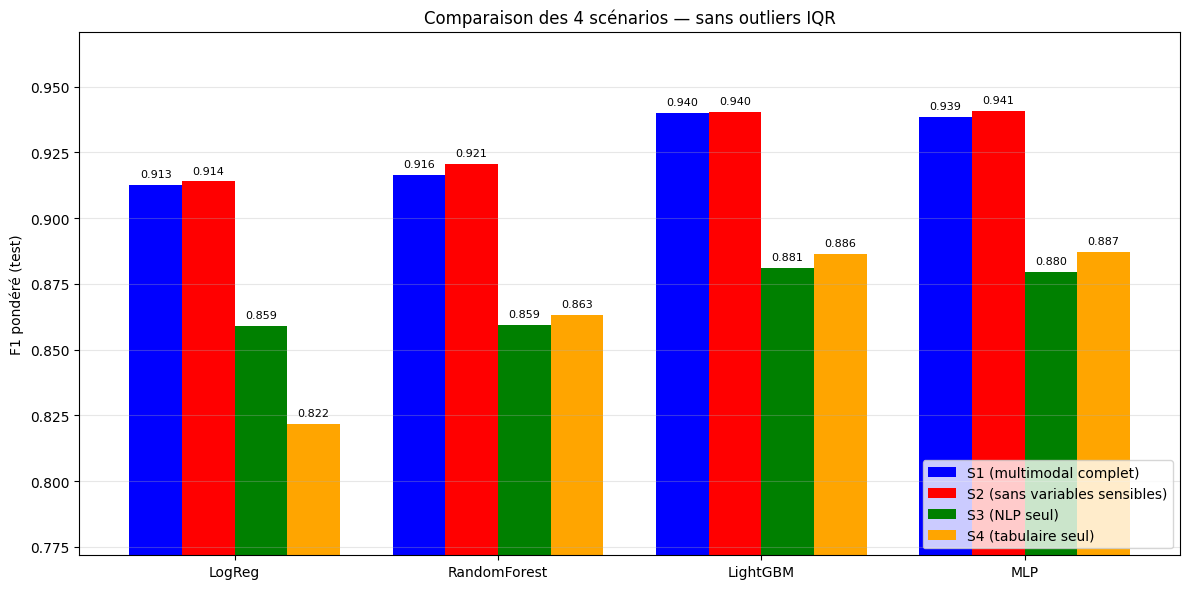

In [45]:
# bar chart F1 par modele/scenario (sans IQR)
models = MODELS
scenario_colors = {'S1': 'blue', 'S2': 'red', 'S3': 'green', 'S4': 'orange'}
scenario_labels = {'S1': 'S1 (multimodal complet)', 'S2': 'S2 (sans variables sensibles)',
                   'S3': 'S3 (NLP seul)', 'S4': 'S4 (tabulaire seul)'}
n_scen = len(SCENARIOS)
width = 0.8 / n_scen
x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(12, 6))
all_vals = []
for i, scen in enumerate(SCENARIOS):
    vals = [results_iqr[scen][m]['test_f1'] for m in models]
    all_vals.extend(vals)
    offset = (i - (n_scen - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=scenario_labels[scen], color=scenario_colors[scen])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003, f'{val:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('F1 pondéré (test)')
ax.set_title('Comparaison des 4 scénarios — sans outliers IQR')
ax.set_ylim(min(all_vals) - 0.05, max(all_vals) + 0.03)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'scenario_comparison_f1_iqr.png', bbox_inches='tight', dpi=150)
plt.show()


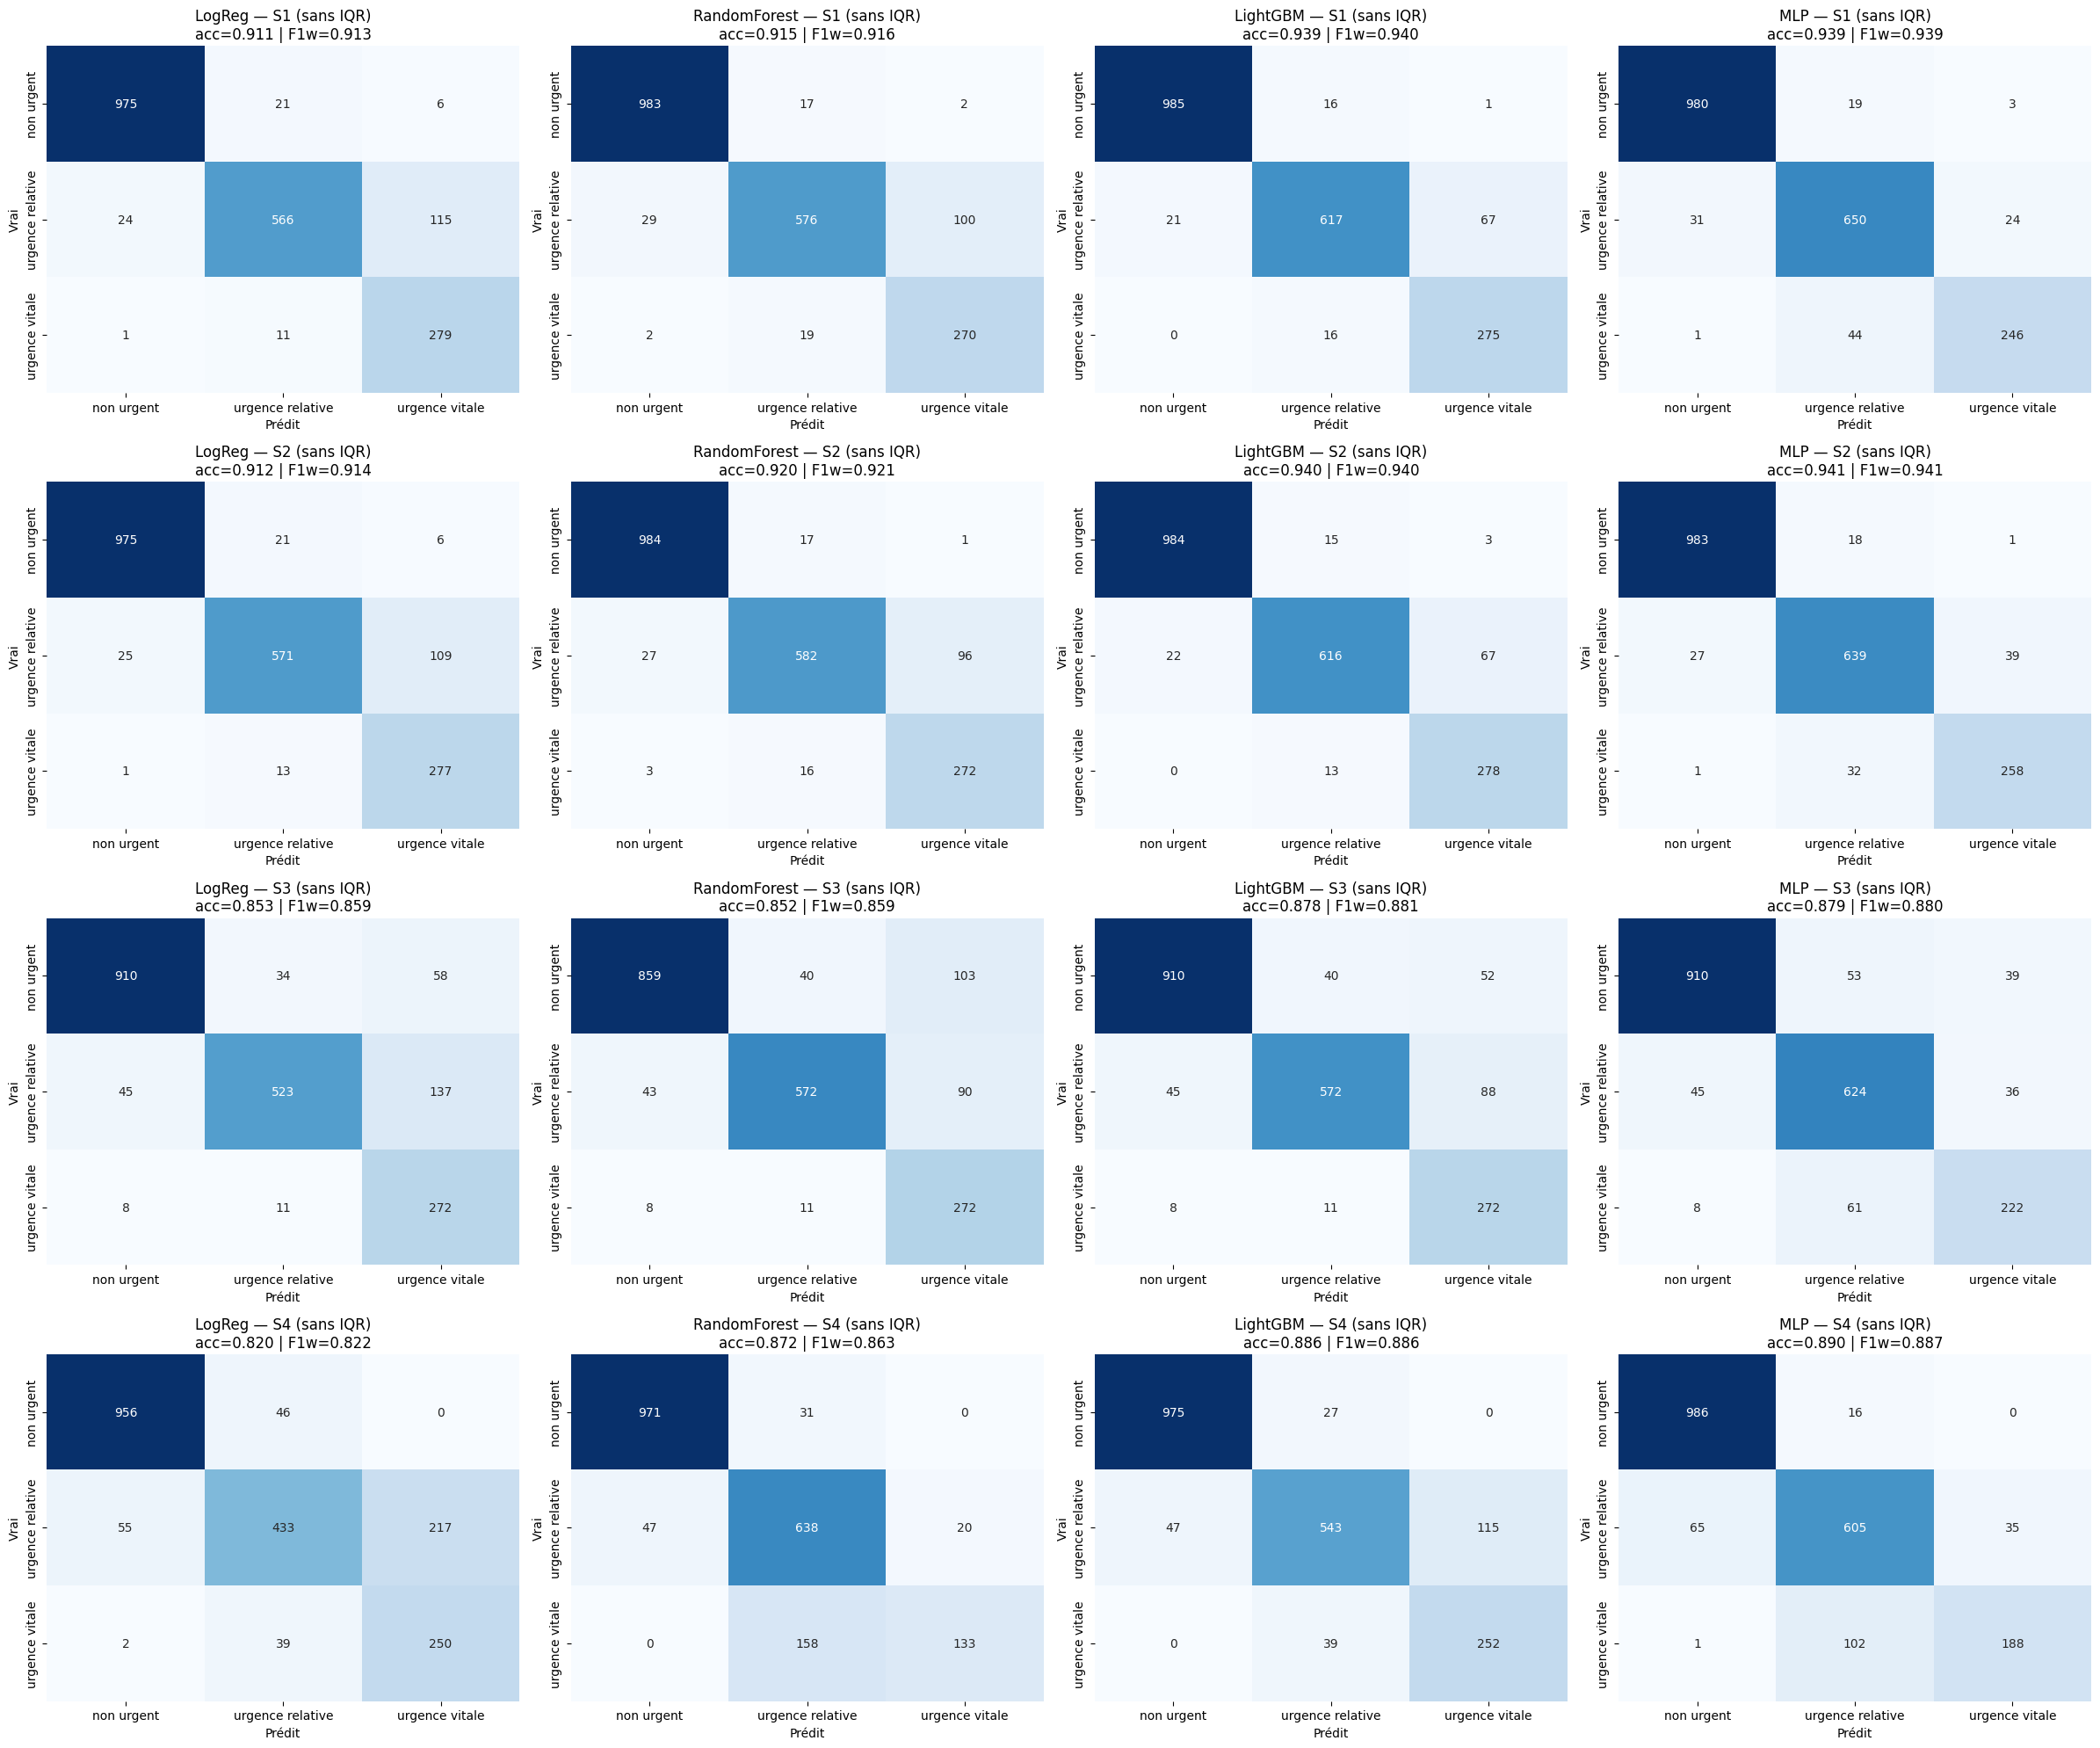

In [46]:
# matrices de confusion (sans IQR)
class_names = ['non urgent', 'urgence relative', 'urgence vitale']
scenario_tags = SCENARIOS
fig, axes = plt.subplots(len(scenario_tags), len(MODELS), figsize=(6 * len(MODELS), 5 * len(scenario_tags)))
for row_idx, scenario_tag in enumerate(scenario_tags):
    for col_idx, name in enumerate(MODELS):
        r = results_iqr[scenario_tag][name]
        ax = axes[row_idx, col_idx]
        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names, cbar=False)
        ax.set_title(f'{name} — {scenario_tag} (sans IQR)\nacc={r["test_acc"]:.3f} | F1w={r["test_f1"]:.3f}')
        ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'confusion_matrices_iqr.png', bbox_inches='tight', dpi=120)
plt.show()


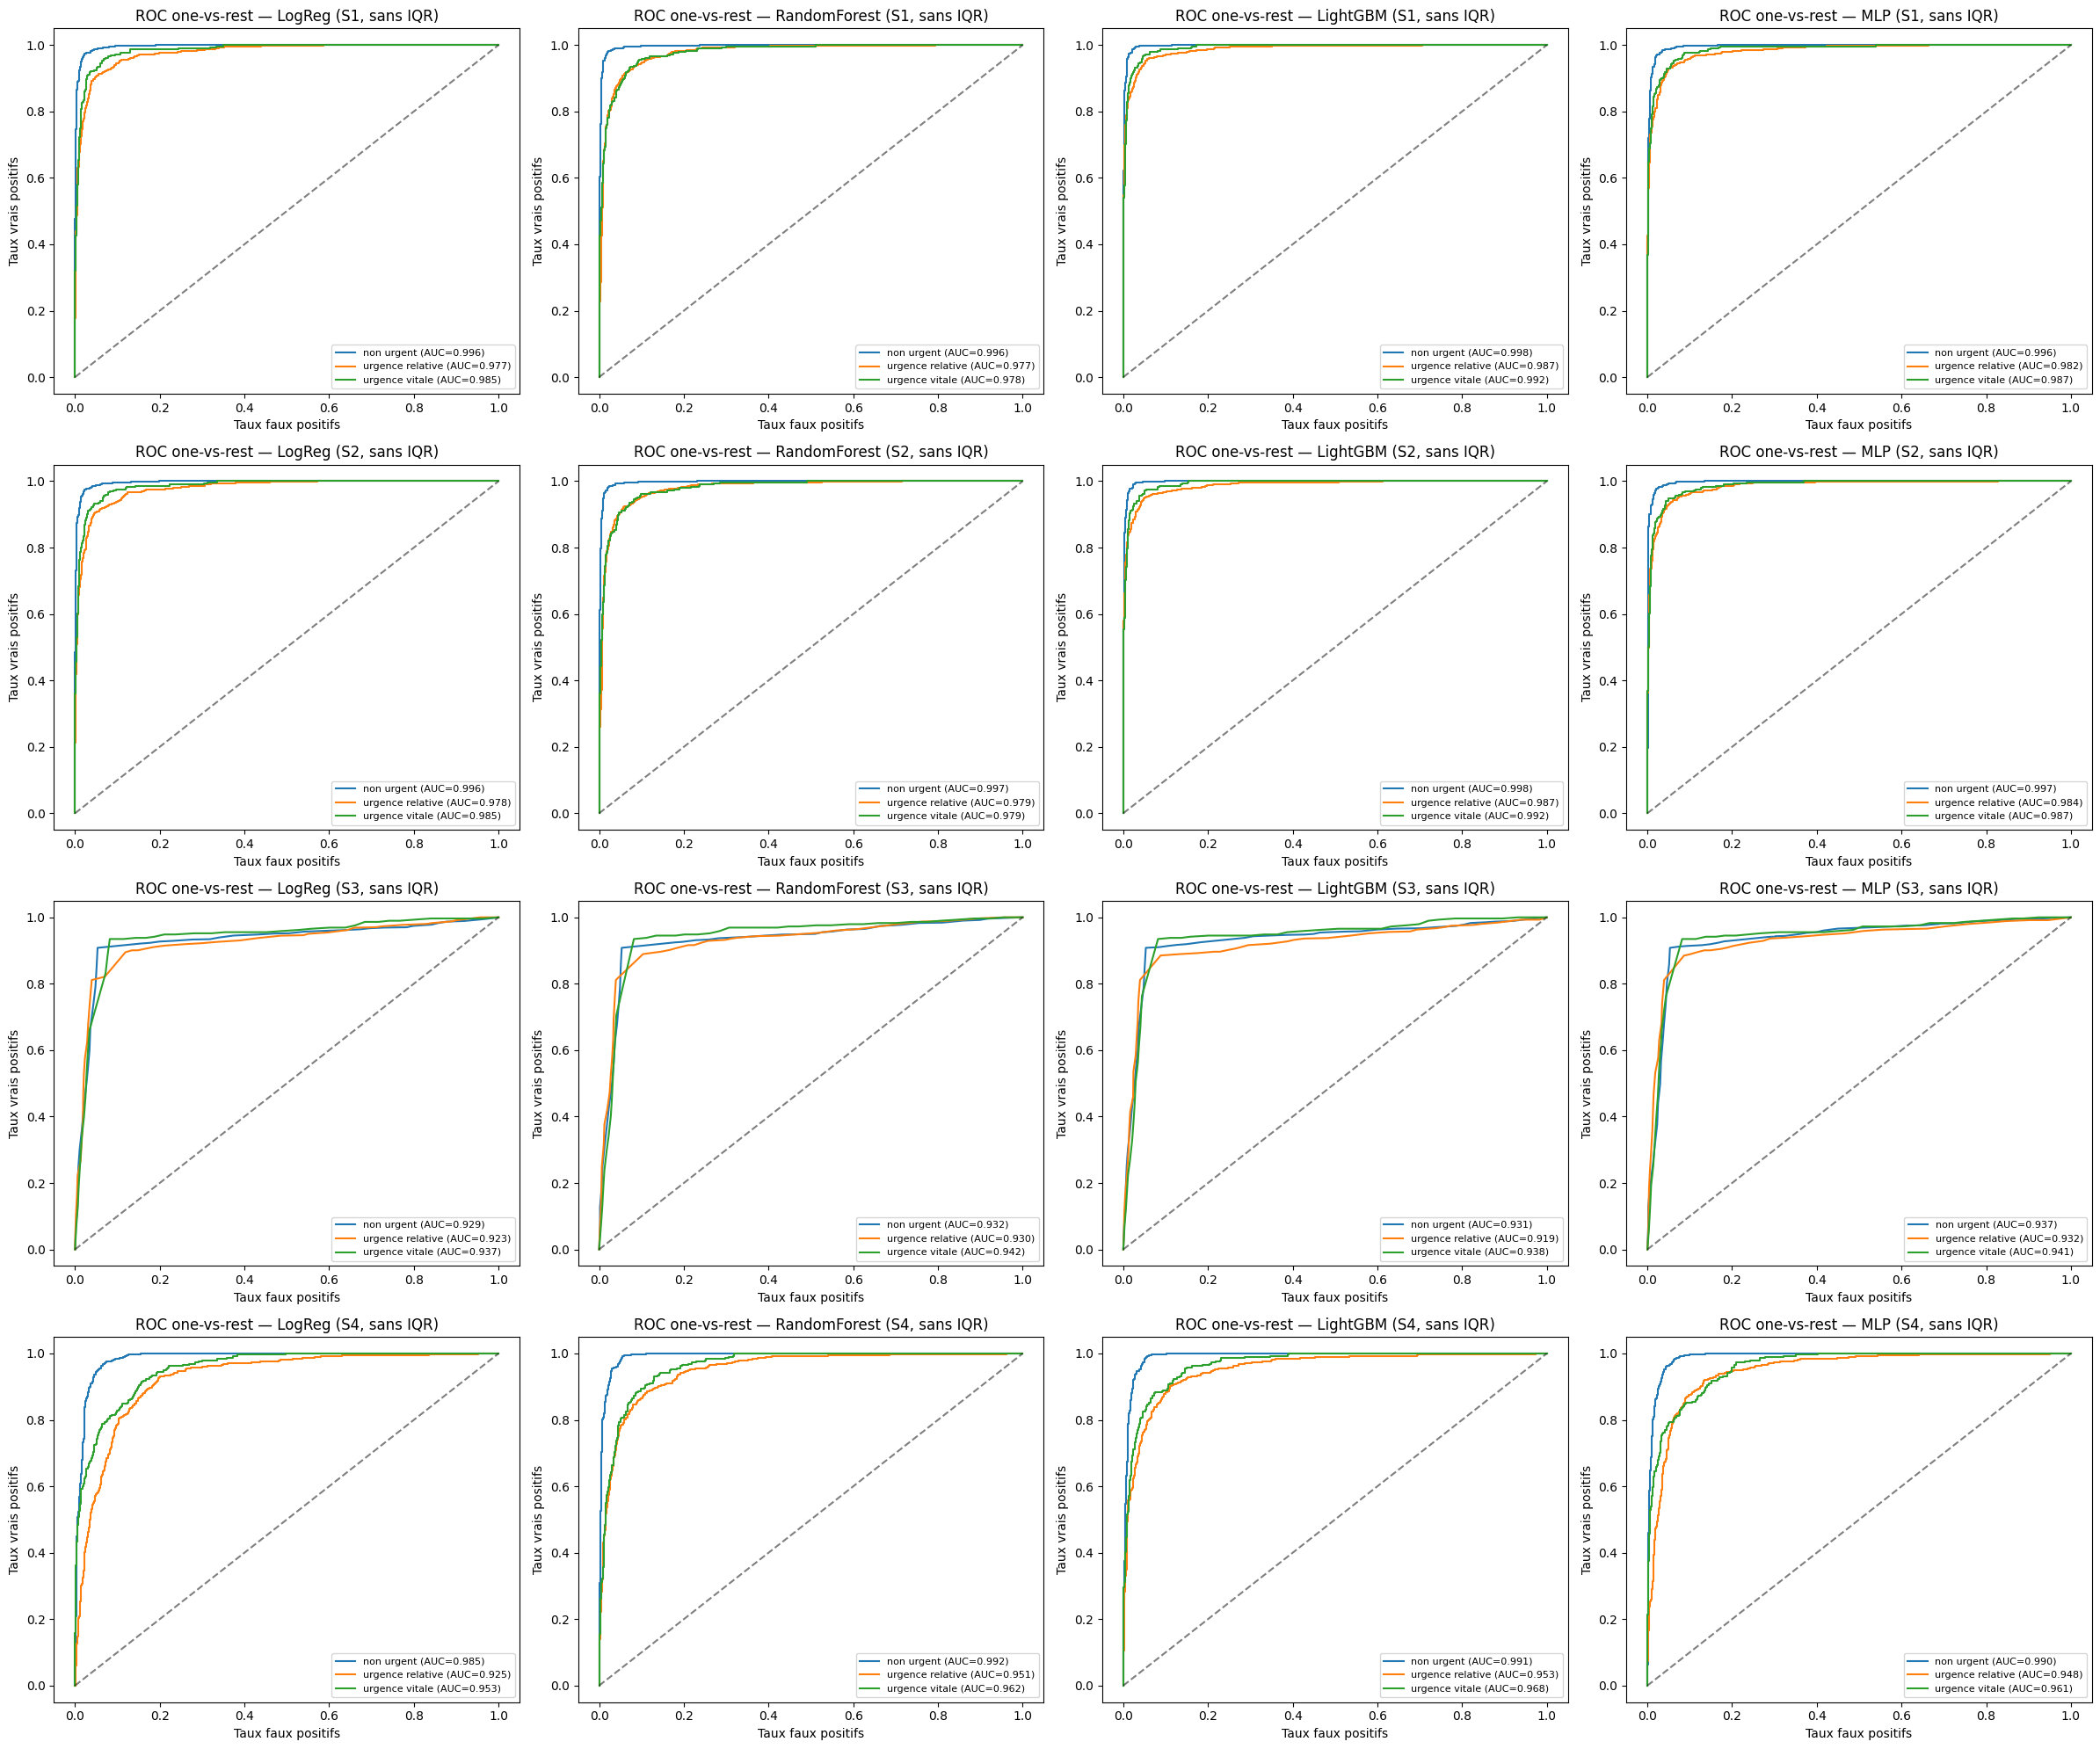

In [47]:
# ROC one-vs-rest (sans IQR)
class_names = ['non urgent', 'urgence relative', 'urgence vitale']
scenario_tags = SCENARIOS
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, axes = plt.subplots(len(scenario_tags), len(MODELS), figsize=(6 * len(MODELS), 5 * len(scenario_tags)))
for row_idx, scenario_tag in enumerate(scenario_tags):
    for col_idx, name in enumerate(MODELS):
        r = results_iqr[scenario_tag][name]
        ax = axes[row_idx, col_idx]
        model = r['model']
        y_score = model.predict_proba(X_test_df) if hasattr(model, 'predict_proba') else model.decision_function(X_test_df)
        for i, cname in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            ax.plot(fpr, tpr, label=f'{cname} (AUC={auc(fpr, tpr):.3f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_xlabel('Taux faux positifs'); ax.set_ylabel('Taux vrais positifs')
        ax.set_title(f'ROC one-vs-rest — {name} ({scenario_tag}, sans IQR)')
        ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'roc_curves_iqr.png', bbox_inches='tight', dpi=120)
plt.show()
